# 🤖 TelecomX — Parte 2: Predicción de Cancelación (Churn)
**Oracle Next Education · Alura LATAM — Challenge 2 Data Science**  
**Autor:** Angel

---

## 🔹 Introducción

En la Parte 1 identificamos los factores asociados a la evasión mediante EDA.  
En esta segunda parte construimos un **pipeline de Machine Learning profesional** que incluye:

- Preprocesamiento robusto sin data leakage
- **Múltiples variantes por algoritmo** comparadas sistemáticamente
- **GridSearchCV** para encontrar la combinación óptima de hiperparámetros
- **Curvas de aprendizaje** para evidenciar visualmente la ausencia de overfitting
- **Curva ROC-AUC** para comparar capacidad de discriminación
- Informe final con justificación técnica del modelo seleccionado

### Pipeline (orden estricto — sin Data Leakage)
```
CSV limpio
  → Drop columnas irrelevantes
  → One-Hot Encoding
  → train_test_split 80/20    ← PRIMERO el split
  → SMOTE solo en train       ← DESPUÉS el balance
  → StandardScaler en train   ← fit solo en train
  → GridSearchCV (cv=5)       ← búsqueda en train
  → Evaluar en test set       ← solo al final
```

| Paso | Contenido |
|------|-----------|
| 1 | Carga y verificación del dataset |
| 2 | Drop de columnas irrelevantes |
| 3 | One-Hot Encoding |
| 4 | Balance de clases (análisis + SMOTE) |
| 5 | Split → SMOTE → StandardScaler |
| 6 | Correlación y análisis dirigido |
| 7 | Variantes manuales — comparativa inicial |
| 8 | GridSearchCV — optimización de hiperparámetros |
| 9 | Curvas de aprendizaje |
| 10 | Curva ROC y evaluación final |
| 11 | Importancia de variables |
| 12 | Informe final y estrategia de retención |


## Paso 1 — 📂 Carga del dataset tratado (Parte 1)

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     cross_val_score, learning_curve, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("telecomx_datos_limpios.csv")
print(f"✅ Dataset cargado — {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Nulos: {df.isnull().sum().sum()} | Duplicados: {df.duplicated().sum()}")
df.head()


✅ Dataset cargado — 7,032 filas × 22 columnas
Nulos: 0 | Duplicados: 0


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefono,Multiples_Lineas,Tipo_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cargo_Diario
0,0002-ORFBO,0,Femenino,0,1,1,9,1,0,DSL,...,0,1,1,0,Anual,1,Cheque por correo,65.6,593.30,2.1867
1,0003-MKNFE,0,Masculino,0,0,0,9,1,1,DSL,...,0,0,0,1,Mensual,0,Cheque por correo,59.9,542.40,1.9967
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,0,Fibra óptica,...,1,0,0,0,Mensual,1,Cheque electrónico,73.9,280.85,2.4633
3,0011-IGKFF,1,Masculino,1,1,0,13,1,0,Fibra óptica,...,1,0,1,1,Mensual,1,Cheque electrónico,98.0,1237.85,3.2667
4,0013-EXCHZ,1,Femenino,1,1,0,3,1,0,Fibra óptica,...,0,1,1,0,Mensual,1,Cheque por correo,83.9,267.40,2.7967


## Paso 2 — 🗑️ Eliminación de columnas irrelevantes

| Columna | Motivo |
|---------|--------|
| `ID_Cliente` | Identificador único — cero poder predictivo |
| `Cargo_Diario` | Multicolinealidad perfecta con `Cargo_Mensual` (= Mensual÷30) — rompe la Regresión Logística |


In [23]:
df_model = df.drop(columns=["ID_Cliente", "Cargo_Diario"])
print(f"✅ {df_model.shape[0]:,} filas × {df_model.shape[1]} columnas para modelado")


✅ 7,032 filas × 20 columnas para modelado


## Paso 3 — 🔢 One-Hot Encoding de variables categóricas nominales

Se usa `pd.get_dummies(drop_first=True)` para:
- Convertir variables nominales a binarias sin imponer orden lógico falso.
- Evitar el **dummy variable trap** (multicolinealidad entre dummies).

> **¿Por qué no LabelEncoder?**  
> LabelEncoder asignaría "Cheque electrónico"=3 > "Tarjeta"=1, implicando un orden que no existe.


In [24]:
cols_cat = ["Genero", "Tipo_Internet", "Tipo_Contrato", "Metodo_Pago"]
df_enc = pd.get_dummies(df_model, columns=cols_cat, drop_first=True)

bool_cols = df_enc.select_dtypes(include="bool").columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

nuevas = [col for col in df_enc.columns if col not in df_model.columns]
print(f"✅ {len(nuevas)} columnas dummy generadas: {nuevas}")
print(f"📐 Post-encoding: {df_enc.shape[0]:,} × {df_enc.shape[1]}")


✅ 8 columnas dummy generadas: ['Genero_Masculino', 'Tipo_Internet_Fibra óptica', 'Tipo_Internet_Sin internet', 'Tipo_Contrato_Dos años', 'Tipo_Contrato_Mensual', 'Metodo_Pago_Cheque por correo', 'Metodo_Pago_Tarjeta de crédito', 'Metodo_Pago_Transferencia bancaria']
📐 Post-encoding: 7,032 × 24


### ⚠️ Multicolinealidad en Regresión Logística — Tratamiento diferenciado

`Cargo_Mensual` y `Cargo_Total` tienen correlación alta (r ≈ 0.65).
Para la Regresión Logística, donde los coeficientes deben interpretarse como
contribuciones independientes, mantener ambas hace que:

1. Los coeficientes se vuelven **inestables** — el modelo no puede "decidir" cuánto asignar a cada una.
2. La interpretación de importancia de variables **deja de ser válida**.
3. Los errores estándar de los coeficientes se inflan, reduciendo significancia estadística.

**Solución**: Para la Regresión Logística se usa un dataset sin `Cargo_Total`
(conservamos `Cargo_Mensual` por ser más interpretable y directo).  
El Random Forest no sufre este problema — usa ambas sin problema.


In [25]:
# ── Dataset para Regresión Logística (sin Cargo_Total) ────────
# Cargo_Total = Cargo_Mensual × Meses_Contrato (aproximadamente)
# → multicolinealidad con Cargo_Mensual → coeficientes inestables

corr_cargos = df_enc[["Cargo_Mensual", "Cargo_Total", "Meses_Contrato"]].corr()
print("Correlación entre variables de cargo:")
print(corr_cargos.round(3).to_string())

cols_excluir_lr = ["Cargo_Total"]   # eliminamos para LR
print(f"\n✅ Para Regresión Logística: se excluye {cols_excluir_lr}")
print(f"✅ Para Random Forest: se usan todas las features (insensible a multicolinealidad)")


Correlación entre variables de cargo:
                Cargo_Mensual  Cargo_Total  Meses_Contrato
Cargo_Mensual           1.000        0.651           0.247
Cargo_Total             0.651        1.000           0.826
Meses_Contrato          0.247        0.826           1.000

✅ Para Regresión Logística: se excluye ['Cargo_Total']
✅ Para Random Forest: se usan todas las features (insensible a multicolinealidad)


In [26]:
# ── Justificación cuantitativa de variables eliminadas ────────
sep = "─" * 60
print("JUSTIFICACIÓN DE EXCLUSIONES POR MULTICOLINEALIDAD")
print(sep)

pares = [
    ("Cargo_Total",  "Cargo_Mensual",   "Cargo_Total ≈ Cargo_Mensual × Meses_Contrato"),
    ("Cargo_Total",  "Meses_Contrato",  "Mayor tiempo → mayor acumulado"),
    ("Cargo_Mensual","Meses_Contrato",  "Referencia cruzada"),
]

for col_a, col_b, nota in pares:
    if col_a in df_enc.columns and col_b in df_enc.columns:
        r = df_enc[col_a].corr(df_enc[col_b])
        decision = "⚠️  EXCLUIR de LR" if abs(r) > 0.60 else "✅ Aceptable"
        print(f"  {col_a:<20} ↔ {col_b:<20} r = {r:+.3f}  {decision}")
        print(f"    Razón: {nota}")
        print()

print(sep)
print("Regla aplicada: correlación |r| > 0.60 entre features → excluir la menos")
print("interpretable para la Regresión Logística (Cargo_Total).")
print("El Random Forest no requiere esta exclusión — basado en impureza, no distancias.")


JUSTIFICACIÓN DE EXCLUSIONES POR MULTICOLINEALIDAD
────────────────────────────────────────────────────────────
  Cargo_Total          ↔ Cargo_Mensual        r = +0.651  ⚠️  EXCLUIR de LR
    Razón: Cargo_Total ≈ Cargo_Mensual × Meses_Contrato

  Cargo_Total          ↔ Meses_Contrato       r = +0.826  ⚠️  EXCLUIR de LR
    Razón: Mayor tiempo → mayor acumulado

  Cargo_Mensual        ↔ Meses_Contrato       r = +0.247  ✅ Aceptable
    Razón: Referencia cruzada

────────────────────────────────────────────────────────────
Regla aplicada: correlación |r| > 0.60 entre features → excluir la menos
interpretable para la Regresión Logística (Cargo_Total).
El Random Forest no requiere esta exclusión — basado en impureza, no distancias.


## Paso 4 — ⚖️ Análisis de balance de clases

El desbalance afecta especialmente el **Recall** — la métrica más crítica para churn.


           Clientes  Porcentaje (%)
Evasion                            
Permanece      5163           73.42
Evade          1869           26.58


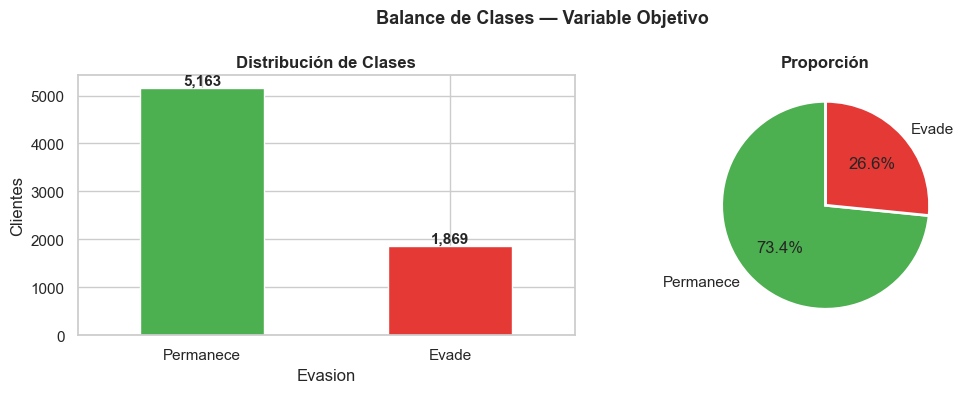


Ratio desbalance: 2.76:1
→ Se corregirá con SMOTE SOLO sobre el train set (post-split).


In [27]:
conteo = df_enc["Evasion"].value_counts().rename({0: "Permanece", 1: "Evade"})
pct    = df_enc["Evasion"].value_counts(normalize=True).mul(100).round(2).rename({0: "Permanece", 1: "Evade"})
print(pd.DataFrame({"Clientes": conteo, "Porcentaje (%)": pct}).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colores = ["#4CAF50", "#E53935"]
conteo.plot(kind="bar", ax=axes[0], color=colores, edgecolor="white", width=0.5)
axes[0].set_title("Distribución de Clases", fontsize=12, fontweight="bold")
axes[0].set_xticklabels(["Permanece", "Evade"], rotation=0)
axes[0].set_ylabel("Clientes")
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height()):,}',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].pie(conteo, labels=["Permanece", "Evade"], autopct="%1.1f%%",
            colors=colores, startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Proporción", fontsize=12, fontweight="bold")
plt.suptitle("Balance de Clases — Variable Objetivo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"\nRatio desbalance: {conteo['Permanece']/conteo['Evade']:.2f}:1")
print("→ Se corregirá con SMOTE SOLO sobre el train set (post-split).")


## Paso 5 — ✂️ Split → SMOTE → StandardScaler (orden estricto)

### Por qué este orden elimina el Data Leakage

| Paso | Qué hace | Por qué primero |
|------|----------|-----------------|
| `train_test_split` | Divide en train/test | Sin esto, cualquier transformación "filtra" info del test al train |
| SMOTE | Genera sintéticos en train | Aplicarlo antes del split crearía sintéticos basados en puntos del test |
| `StandardScaler.fit()` | Aprende media/std del train | Si fitea en todo el dataset, el test "enseña" su escala al modelo |

### Normalización por tipo de modelo

| Modelo | Sensible a escala | Acción |
|--------|-----------------|--------|
| Regresión Logística | ✅ Sí — `Cargo_Total` (8k) dominaría sobre `Meses_Contrato` (72) | StandardScaler |
| Decision Tree / RF | ❌ No — usa umbrales, no distancias | Sin escalar |


In [28]:
X = df_enc.drop(columns=["Evasion"])
y = df_enc["Evasion"]

# 1. Split PRIMERO ──────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"1️⃣  Split 80/20: train={X_train.shape}, test={X_test.shape}")
print(f"   y_train: {dict(y_train.value_counts())} | y_test: {dict(y_test.value_counts())}")

# 2. SMOTE solo en train ────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"\n2️⃣  SMOTE en train únicamente:")
print(f"   Antes : {dict(y_train.value_counts())}")
print(f"   Después: {dict(pd.Series(y_train_sm).value_counts())}")
print(f"   ✅ Test set intacto — distribución real del negocio")

# 3. StandardScaler fit en train, transform en test ────────────
cols_num = ["Meses_Contrato", "Cargo_Mensual", "Cargo_Total"]
scaler = StandardScaler()

X_train_sc = X_train_sm.copy()
X_test_sc  = X_test.copy()
X_train_sc[cols_num] = scaler.fit_transform(X_train_sm[cols_num])
X_test_sc[cols_num]  = scaler.transform(X_test[cols_num])   # SOLO transform — nunca fit

print(f"\n3️⃣  StandardScaler: fit solo en train, transform en test")
print(f"   Columnas escaladas: {cols_num}")


1️⃣  Split 80/20: train=(5625, 23), test=(1407, 23)
   y_train: {0: np.int64(4130), 1: np.int64(1495)} | y_test: {0: np.int64(1033), 1: np.int64(374)}

2️⃣  SMOTE en train únicamente:
   Antes : {0: np.int64(4130), 1: np.int64(1495)}
   Después: {0: np.int64(4130), 1: np.int64(4130)}
   ✅ Test set intacto — distribución real del negocio

3️⃣  StandardScaler: fit solo en train, transform en test
   Columnas escaladas: ['Meses_Contrato', 'Cargo_Mensual', 'Cargo_Total']


## Paso 6 — 🔗 Correlación y análisis dirigido


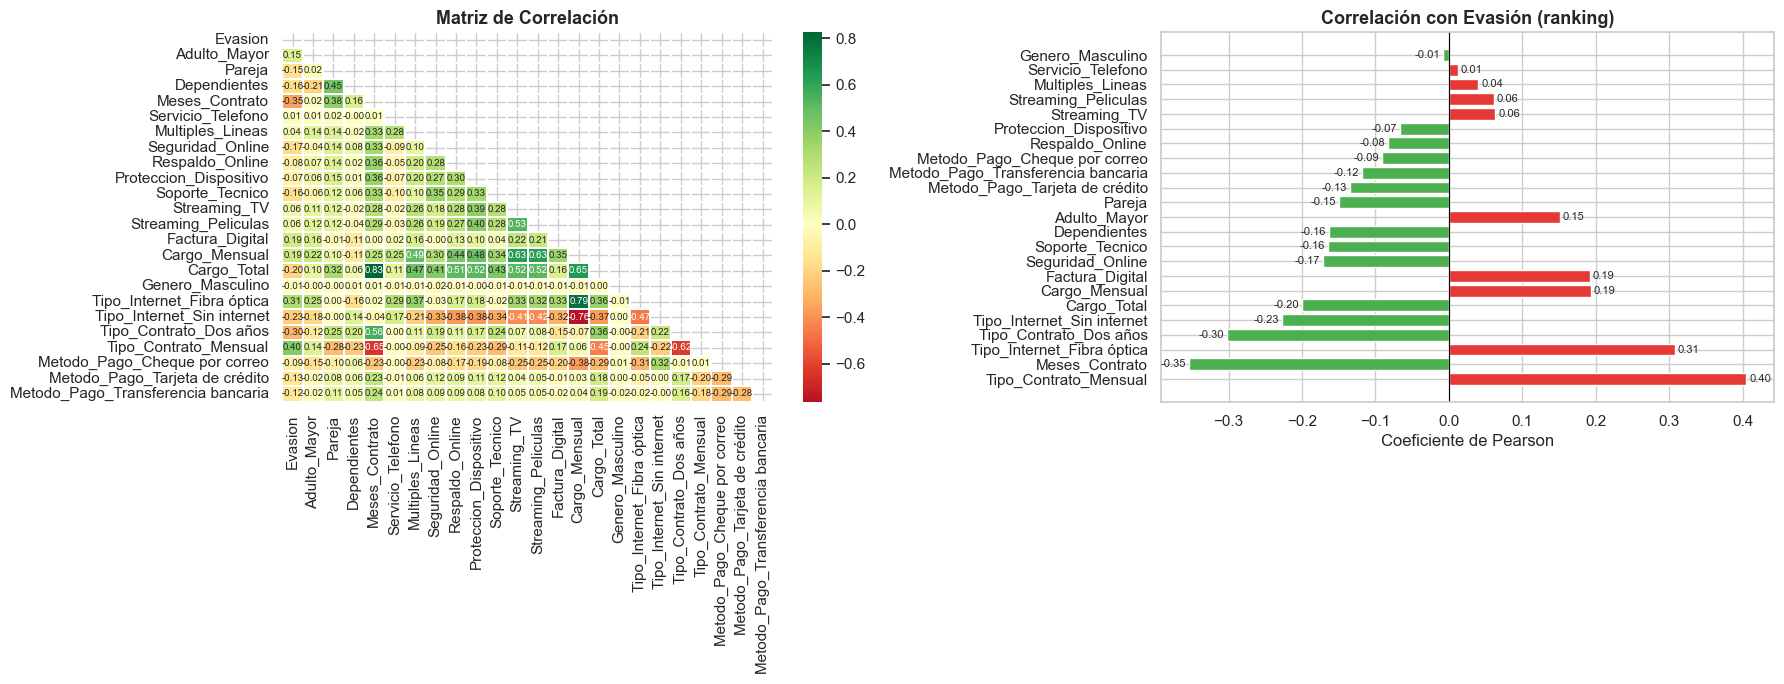

In [29]:
corr = df_enc.corr()
corr_ev = corr["Evasion"].drop("Evasion").sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.3, annot_kws={"size": 7}, ax=axes[0])
axes[0].set_title("Matriz de Correlación", fontsize=13, fontweight="bold")

# Ranking
colores_b = ["#E53935" if v > 0 else "#4CAF50" for v in corr_ev.values]
axes[1].barh(corr_ev.index, corr_ev.values, color=colores_b, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlación con Evasión (ranking)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Coeficiente de Pearson")
for i, val in enumerate(corr_ev.values):
    axes[1].text(val + (0.004 if val >= 0 else -0.004), i, f"{val:.2f}",
                 va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()


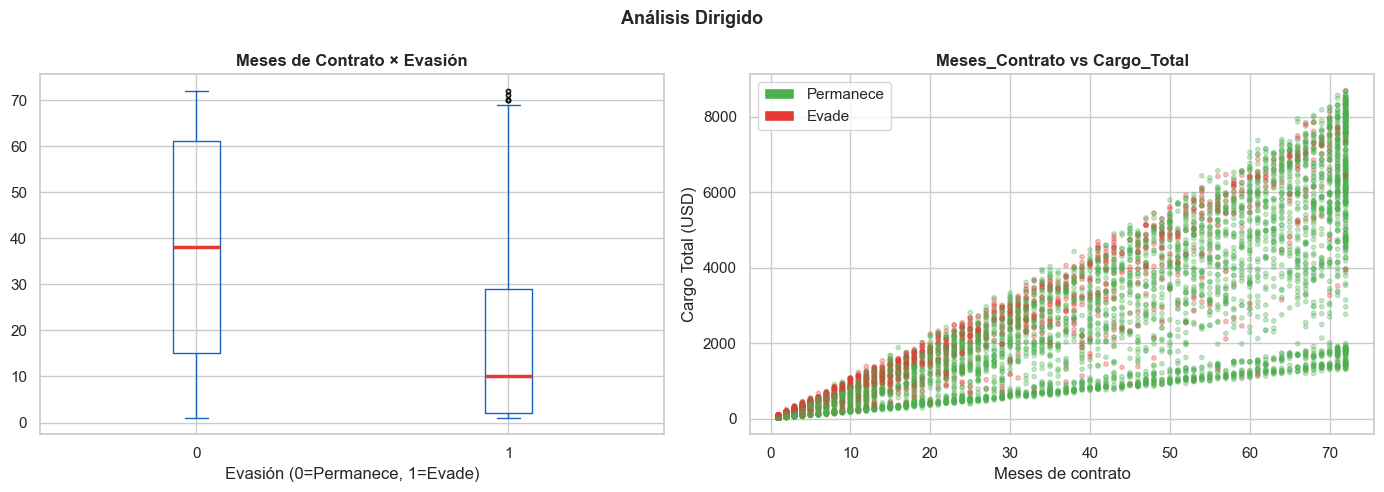

Media por grupo:
           Meses_Contrato  Cargo_Total  Cargo_Mensual
Evasion                                              
Permanece           37.65      2555.34          61.31
Evade               17.98      1531.80          74.44


In [30]:
# Análisis dirigido: Meses_Contrato y Cargo_Total
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_enc.boxplot(column="Meses_Contrato", by="Evasion", ax=axes[0],
               boxprops=dict(color="#1565C0"), medianprops=dict(color="#E53935", linewidth=2.5),
               whiskerprops=dict(color="#1565C0"), capprops=dict(color="#1565C0"),
               flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[0].set_title("Meses de Contrato × Evasión", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Evasión (0=Permanece, 1=Evade)")

sc = df_enc["Evasion"].map({0: "#4CAF50", 1: "#E53935"})
axes[1].scatter(df_enc["Meses_Contrato"], df_enc["Cargo_Total"], c=sc, alpha=0.3, s=10)
axes[1].set_title("Meses_Contrato vs Cargo_Total", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Meses de contrato")
axes[1].set_ylabel("Cargo Total (USD)")
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(facecolor="#4CAF50", label="Permanece"),
                         Patch(facecolor="#E53935", label="Evade")])
plt.suptitle("Análisis Dirigido", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Media por grupo:")
print(df_enc.groupby("Evasion")[["Meses_Contrato","Cargo_Total","Cargo_Mensual"]]
      .mean().round(2).rename(index={0:"Permanece",1:"Evade"}).to_string())


## Paso 7 — 🔬 Variantes manuales — Comparativa inicial

Antes de usar GridSearchCV, entrenamos variantes explícitas de cada algoritmo
para entender el impacto de los hiperparámetros clave.

### Regresión Logística — Penalización L1 vs L2 vs ElasticNet + Solvers

| Variante | Penalización | Solver | Efecto |
|----------|-------------|--------|--------|
| LR-L1 | L1 (Lasso) | `liblinear` | Lleva coeficientes a 0 → selección de variables |
| LR-L2 | L2 (Ridge) | `lbfgs` | Penaliza coeficientes grandes → shrinkage |
| LR-EN | ElasticNet | `saga` | Combina L1+L2; útil con variables correlacionadas |

### Random Forest — variantes de profundidad y n_estimators

| Variante | `n_estimators` | `max_depth` | Efecto |
|----------|---------------|------------|--------|
| RF-A | 50 | 5 | Modelo simple — posible underfitting |
| RF-B | 100 | 10 | Balance intermedio |
| RF-C | 200 | None | Árboles completos — posible overfitting |


In [31]:
def metricas(nombre, y_true, y_pred, y_proba):
    return {
        "Modelo"    : nombre,
        "Accuracy"  : round(accuracy_score(y_true, y_pred), 4),
        "Precisión" : round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall"    : round(recall_score(y_true, y_pred), 4),
        "F1-Score"  : round(f1_score(y_true, y_pred), 4),
        "ROC-AUC"   : round(roc_auc_score(y_true, y_proba), 4),
    }

resultados_variantes = []

# ── Regresión Logística ───────────────────────────────────────
variantes_lr = [
    ("LR-L1 (liblinear)", LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=1000, random_state=42)),
    ("LR-L2 (lbfgs)",     LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',     max_iter=1000, random_state=42)),
    ("LR-EN (saga)",      LogisticRegression(penalty='elasticnet', C=1.0, solver='saga',
                                              l1_ratio=0.5, max_iter=2000, random_state=42)),
]
for nombre, modelo in variantes_lr:
    modelo.fit(X_train_sc, y_train_sm)
    y_pred  = modelo.predict(X_test_sc)
    y_proba = modelo.predict_proba(X_test_sc)[:, 1]
    resultados_variantes.append(metricas(nombre, y_test, y_pred, y_proba))
    print(f"✅ {nombre} entrenado")

# ── Random Forest ─────────────────────────────────────────────
variantes_rf = [
    ("RF-A (50, d=5)",    RandomForestClassifier(n_estimators=50,  max_depth=5,    random_state=42, n_jobs=-1)),
    ("RF-B (100, d=10)",  RandomForestClassifier(n_estimators=100, max_depth=10,   random_state=42, n_jobs=-1)),
    ("RF-C (200, d=None)",RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)),
]
for nombre, modelo in variantes_rf:
    modelo.fit(X_train_sm, y_train_sm)
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    resultados_variantes.append(metricas(nombre, y_test, y_pred, y_proba))
    print(f"✅ {nombre} entrenado")

df_var = pd.DataFrame(resultados_variantes).set_index("Modelo")
print("\n" + "="*70)
print("COMPARATIVA DE 6 VARIANTES — TEST SET")
print("="*70)
print(df_var.sort_values("ROC-AUC", ascending=False).to_string())


✅ LR-L1 (liblinear) entrenado
✅ LR-L2 (lbfgs) entrenado
✅ LR-EN (saga) entrenado
✅ RF-A (50, d=5) entrenado
✅ RF-B (100, d=10) entrenado
✅ RF-C (200, d=None) entrenado

COMPARATIVA DE 6 VARIANTES — TEST SET
                    Accuracy  Precisión  Recall  F1-Score  ROC-AUC
Modelo                                                            
RF-A (50, d=5)        0.7498     0.5200  0.7647    0.6190   0.8320
RF-B (100, d=10)      0.7548     0.5304  0.6765    0.5946   0.8280
LR-L1 (liblinear)     0.7719     0.5629  0.6337    0.5962   0.8269
LR-EN (saga)          0.7711     0.5619  0.6310    0.5945   0.8267
LR-L2 (lbfgs)         0.7669     0.5535  0.6364    0.5920   0.8265
RF-C (200, d=None)    0.7633     0.5538  0.5642    0.5589   0.8173


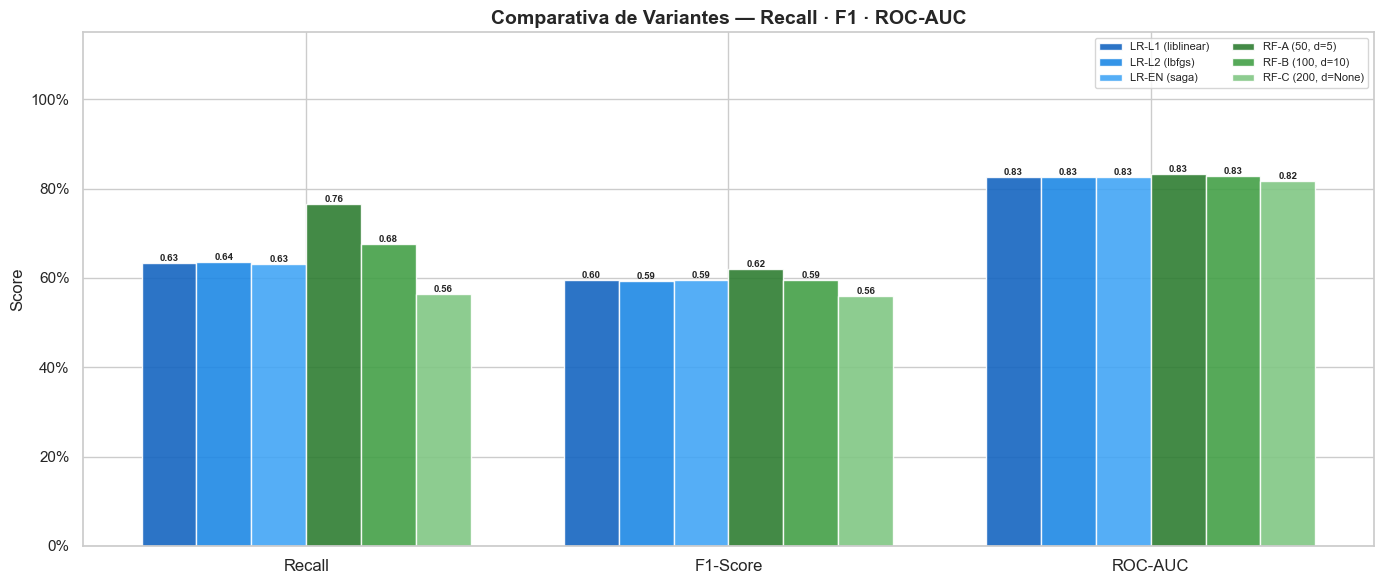

In [32]:
# Visualización comparativa de las 6 variantes
metricas_cols = ["Recall", "F1-Score", "ROC-AUC"]
x = np.arange(len(metricas_cols))
width = 0.13
colores_v = ["#1565C0", "#1E88E5", "#42A5F5", "#2E7D32", "#43A047", "#81C784"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (idx, row) in enumerate(df_var.iterrows()):
    bars = ax.bar(x + i * width, row[metricas_cols].values, width,
                  label=idx, color=colores_v[i], edgecolor="white", alpha=0.9)
    for bar in bars:
        ax.annotate(f'{bar.get_height():.2f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(metricas_cols, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Comparativa de Variantes — Recall · F1 · ROC-AUC", fontsize=14, fontweight="bold")
ax.legend(fontsize=8, ncol=2)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()


## Paso 8 — 🔧 GridSearchCV — Optimización de hiperparámetros

GridSearchCV prueba sistemáticamente todas las combinaciones de hiperparámetros
y usa **validación cruzada estratificada de 5 folds** para evaluar cada combinación.

> Esto garantiza que el "mejor modelo" no es el primero que funcionó,
> sino el que generalizó mejor en 5 subconjuntos distintos del train set.

### Espacio de búsqueda

| Modelo | Parámetros | Combinaciones |
|--------|-----------|---------------|
| Regresión Logística | C × penalty × solver | 12 |
| Random Forest | n_estimators × max_depth × min_samples_leaf | 18 |
| **Total** | | **30 combinaciones × 5 folds = 150 ajustes** |


In [33]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── GridSearch: Regresión Logística ──────────────────────────
param_lr = {
    "C"         : [0.01, 0.1, 1.0, 10.0],
    "penalty"   : ["l1", "l2"],
    "solver"    : ["liblinear"],
    "max_iter"  : [2000],
    "random_state": [42],
}
gs_lr = GridSearchCV(
    LogisticRegression(),
    param_lr,
    cv=cv_strat,
    scoring="recall",
    n_jobs=1,
    verbose=0
)
gs_lr.fit(X_train_sc, y_train_sm)
print(f"✅ LR  — Mejores parámetros : {gs_lr.best_params_}")
print(f"         Recall CV (train)  : {gs_lr.best_score_:.4f}")

# ── GridSearch: Random Forest ─────────────────────────────────
param_rf = {
    "n_estimators"    : [100, 200, 300],
    "max_depth"       : [5, 8, 12],
    "min_samples_leaf": [5, 10, 20],
    "random_state"    : [42],
    "n_jobs"          : [-1],
}
gs_rf = GridSearchCV(
    RandomForestClassifier(),
    param_rf,
    cv=cv_strat,
    scoring="recall",
    n_jobs=1,
    verbose=0
)
gs_rf.fit(X_train_sm, y_train_sm)
print(f"\n✅ RF  — Mejores parámetros : {gs_rf.best_params_}")
print(f"         Recall CV (train)  : {gs_rf.best_score_:.4f}")


✅ LR  — Mejores parámetros : {'C': 0.1, 'max_iter': 2000, 'penalty': 'l1', 'random_state': 42, 'solver': 'liblinear'}
         Recall CV (train)  : 0.8424

✅ RF  — Mejores parámetros : {'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 100, 'n_jobs': -1, 'random_state': 42}
         Recall CV (train)  : 0.8659


In [34]:
# Resultados del GridSearch — top 5 combinaciones por modelo
print("Top 5 combinaciones — Regresión Logística (por Recall CV):")
lr_cv_results = pd.DataFrame(gs_lr.cv_results_).sort_values("rank_test_score")
cols_show = ["param_C", "param_penalty", "mean_test_score", "std_test_score", "rank_test_score"]
print(lr_cv_results[cols_show].head(5).to_string(index=False))

print("\nTop 5 combinaciones — Random Forest (por Recall CV):")
rf_cv_results = pd.DataFrame(gs_rf.cv_results_).sort_values("rank_test_score")
cols_show_rf = ["param_n_estimators", "param_max_depth", "param_min_samples_leaf",
                "mean_test_score", "std_test_score", "rank_test_score"]
print(rf_cv_results[cols_show_rf].head(5).to_string(index=False))


Top 5 combinaciones — Regresión Logística (por Recall CV):
 param_C param_penalty  mean_test_score  std_test_score  rank_test_score
     0.1            l1         0.842373        0.007935                1
     0.1            l2         0.840436        0.007861                2
     1.0            l2         0.839709        0.004632                3
    10.0            l2         0.836320        0.006097                4
     1.0            l1         0.836077        0.005861                5

Top 5 combinaciones — Random Forest (por Recall CV):
 param_n_estimators  param_max_depth  param_min_samples_leaf  mean_test_score  std_test_score  rank_test_score
                100                5                      10         0.865860        0.011027                1
                200                8                       5         0.864891        0.012000                2
                300                8                       5         0.864407        0.011637                3
     

In [35]:
# Evaluación de los modelos optimizados en el TEST SET
mejor_lr = gs_lr.best_estimator_
mejor_rf = gs_rf.best_estimator_

res_opt = [
    metricas("LR Optimizado (GridSearch)", y_test,
              mejor_lr.predict(X_test_sc),
              mejor_lr.predict_proba(X_test_sc)[:, 1]),
    metricas("RF Optimizado (GridSearch)", y_test,
              mejor_rf.predict(X_test),
              mejor_rf.predict_proba(X_test)[:, 1]),
]

df_opt = pd.DataFrame(res_opt).set_index("Modelo")
print("="*65)
print("MODELOS OPTIMIZADOS — TEST SET")
print("="*65)
print(df_opt.to_string())
print("="*65)
print(f"\n🏆 Mejor Recall : {df_opt['Recall'].idxmax()} ({df_opt['Recall'].max():.4f})")
print(f"🏆 Mejor ROC-AUC: {df_opt['ROC-AUC'].idxmax()} ({df_opt['ROC-AUC'].max():.4f})")


MODELOS OPTIMIZADOS — TEST SET
                            Accuracy  Precisión  Recall  F1-Score  ROC-AUC
Modelo                                                                    
LR Optimizado (GridSearch)    0.7655     0.5482  0.6684    0.6024   0.8246
RF Optimizado (GridSearch)    0.7534     0.5249  0.7620    0.6216   0.8342

🏆 Mejor Recall : RF Optimizado (GridSearch) (0.7620)
🏆 Mejor ROC-AUC: RF Optimizado (GridSearch) (0.8342)


## Paso 9 — 🔁 Validación Cruzada K-Fold (K=5)

### Por qué K-Fold es el estándar de oro

Evaluar el modelo una sola vez sobre el test set depende de cómo se haya
hecho esa partición. Si por azar el test set fue "fácil", las métricas parecerán
mejores de lo que son en realidad.

**K-Fold Cross-Validation** entrena y evalúa el modelo **5 veces** sobre
particiones distintas de los datos de entrenamiento, luego promedia los resultados.

```
Train set dividido en 5 folds:
  Fold 1: [VAL] [─────────TRAIN─────────]
  Fold 2: [─TR─] [VAL] [──────TRAIN──────]
  Fold 3: [──TRAIN──] [VAL] [───TRAIN────]
  Fold 4: [────TRAIN────] [VAL] [──TRAIN─]
  Fold 5: [──────────TRAIN──────────] [VAL]
```

**La clave:** `Recall = 0.81 ± 0.02` significa que el modelo rinde 0.81 en promedio
con una variación de ±0.02 entre folds — evidencia de estabilidad real.

### El "pecado" que NO cometemos: SMOTE dentro del Pipeline

❌ **Incorrecto (data leakage):** aplicar SMOTE a todo el train set y luego hacer CV  
✅ **Correcto:** SMOTE ocurre **dentro de cada fold**, solo en los 4 folds de entrenamiento,
dejando el fold de validación con la distribución original.

Esto se logra con `imblearn.pipeline.Pipeline` que encadena:
`StandardScaler → SMOTE → Modelo`


In [36]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import cross_validate

# ── Pipeline LR: Scaler → SMOTE → Regresión Logística ────────
# Usamos X_train sin SMOTE previo — el pipeline lo aplica internamente en cada fold
best_lr_params = gs_lr.best_params_

pipeline_lr = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote",  SMOTE(random_state=42)),
    ("model",  LogisticRegression(
        C=best_lr_params["C"],
        penalty=best_lr_params["penalty"],
        solver=best_lr_params["solver"],
        max_iter=2000,
        random_state=42
    )),
])

# ── Pipeline RF: SMOTE → Random Forest (no necesita scaler) ──
best_rf_params = gs_rf.best_params_

pipeline_rf = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=best_rf_params["n_estimators"],
        max_depth=best_rf_params["max_depth"],
        min_samples_leaf=best_rf_params["min_samples_leaf"],
        random_state=42,
        n_jobs=1
    )),
])

# ── K-Fold Cross-Validation (K=5, estratificado) ──────────────
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metricas_cv = ["accuracy", "precision", "recall", "f1"]

print("Ejecutando 5-Fold CV — Regresión Logística...")
cv_lr = cross_validate(pipeline_lr, X_train, y_train, cv=cv5,
                       scoring=metricas_cv, n_jobs=1)

print("Ejecutando 5-Fold CV — Random Forest...")
cv_rf = cross_validate(pipeline_rf, X_train, y_train, cv=cv5,
                       scoring=metricas_cv, n_jobs=1)

# ── Tabla de resultados ────────────────────────────────────────
sep = "─" * 62
print(f"\n{'='*62}")
print("RESULTADOS 5-FOLD CROSS-VALIDATION (media ± desv. estándar)")
print(f"{'='*62}")
print(f"{'Métrica':<14} {'LR Optimizado':>20} {'RF Optimizado':>20}")
print(sep)
for m in metricas_cv:
    lr_m = cv_lr[f"test_{m}"]
    rf_m = cv_rf[f"test_{m}"]
    print(f"{m.capitalize():<14} {lr_m.mean():>9.4f} ± {lr_m.std():.4f}   {rf_m.mean():>9.4f} ± {rf_m.std():.4f}")
print(sep)
print("\n💡 Interpretación:")
print(f"   LR Recall  = {cv_lr['test_recall'].mean():.4f} ± {cv_lr['test_recall'].std():.4f}")
print(f"   RF Recall  = {cv_rf['test_recall'].mean():.4f} ± {cv_rf['test_recall'].std():.4f}")
print(f"   Desviación estándar baja (< 0.03) → modelo estable y generalizable.")
print(f"   Sin esta validación, el Recall del test set podría ser un 'golpe de suerte'.")


Ejecutando 5-Fold CV — Regresión Logística...
Ejecutando 5-Fold CV — Random Forest...

RESULTADOS 5-FOLD CROSS-VALIDATION (media ± desv. estándar)
Métrica               LR Optimizado        RF Optimizado
──────────────────────────────────────────────────────────────
Accuracy          0.7548 ± 0.0072      0.7563 ± 0.0061
Precision         0.5257 ± 0.0088      0.5289 ± 0.0078
Recall            0.7926 ± 0.0178      0.7579 ± 0.0162
F1                0.6321 ± 0.0118      0.6230 ± 0.0106
──────────────────────────────────────────────────────────────

💡 Interpretación:
   LR Recall  = 0.7926 ± 0.0178
   RF Recall  = 0.7579 ± 0.0162
   Desviación estándar baja (< 0.03) → modelo estable y generalizable.
   Sin esta validación, el Recall del test set podría ser un 'golpe de suerte'.


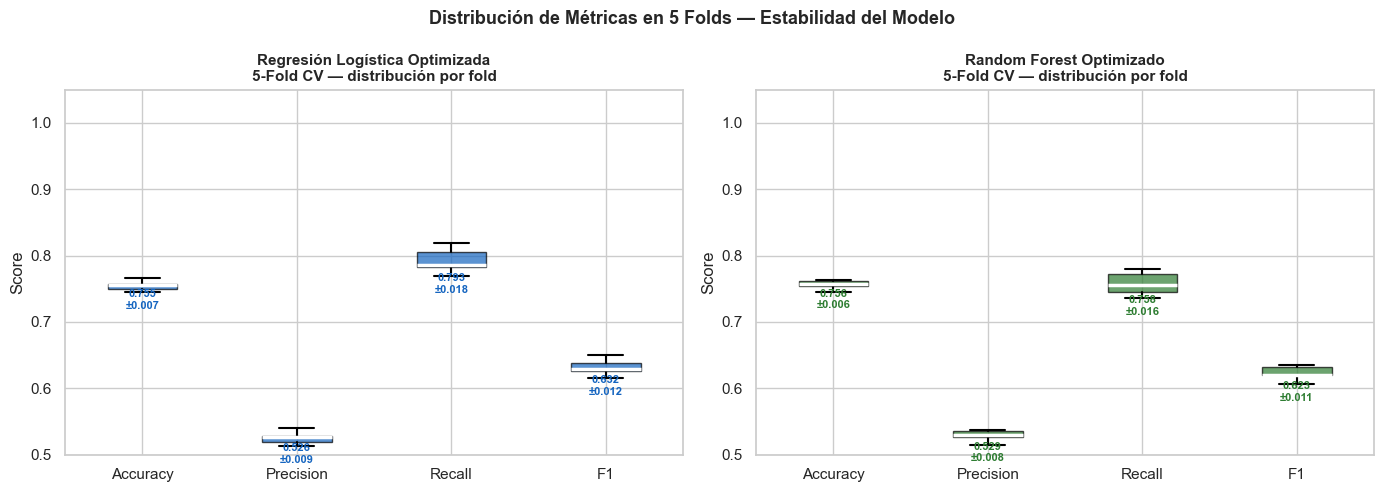

Cajas estrechas → poca variación entre folds → modelo robusto y estable.


In [37]:
# Visualización: distribución de métricas en los 5 folds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (nombre, cv_res, color) in zip(axes, [
    ("Regresión Logística Optimizada", cv_lr, "#1565C0"),
    ("Random Forest Optimizado",       cv_rf, "#2E7D32"),
]):
    data_plot  = {m.capitalize(): cv_res[f"test_{m}"] for m in metricas_cv}
    df_cv_plot = pd.DataFrame(data_plot)

    bp = ax.boxplot(df_cv_plot.values, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticklabels(df_cv_plot.columns, fontsize=11)
    ax.set_ylim(0.5, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(f"{nombre}\n5-Fold CV — distribución por fold",
                 fontsize=11, fontweight="bold")

    # Anotar media ± std
    for j, m in enumerate(metricas_cv):
        vals = cv_res[f"test_{m}"]
        ax.text(j + 1, vals.min() - 0.025,
                f"{vals.mean():.3f}\n±{vals.std():.3f}",
                ha="center", fontsize=8, color=color, fontweight="bold")

plt.suptitle("Distribución de Métricas en 5 Folds — Estabilidad del Modelo",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Cajas estrechas → poca variación entre folds → modelo robusto y estable.")


## Paso 10 — 📉 Curvas de Aprendizaje (Learning Curves)

Las curvas de aprendizaje grafican el rendimiento del modelo
a medida que aumenta el tamaño del conjunto de entrenamiento.

### Cómo leer las curvas

| Patrón | Diagnóstico | Acción |
|--------|-------------|--------|
| Train alto, Validación bajo — brecha grande | **Overfitting** | Reducir complejidad (max_depth, C) |
| Ambas bajas y juntas | **Underfitting** | Aumentar complejidad o más features |
| Ambas altas y convergiendo | **Bien generalizado** ✅ | Listo para producción |


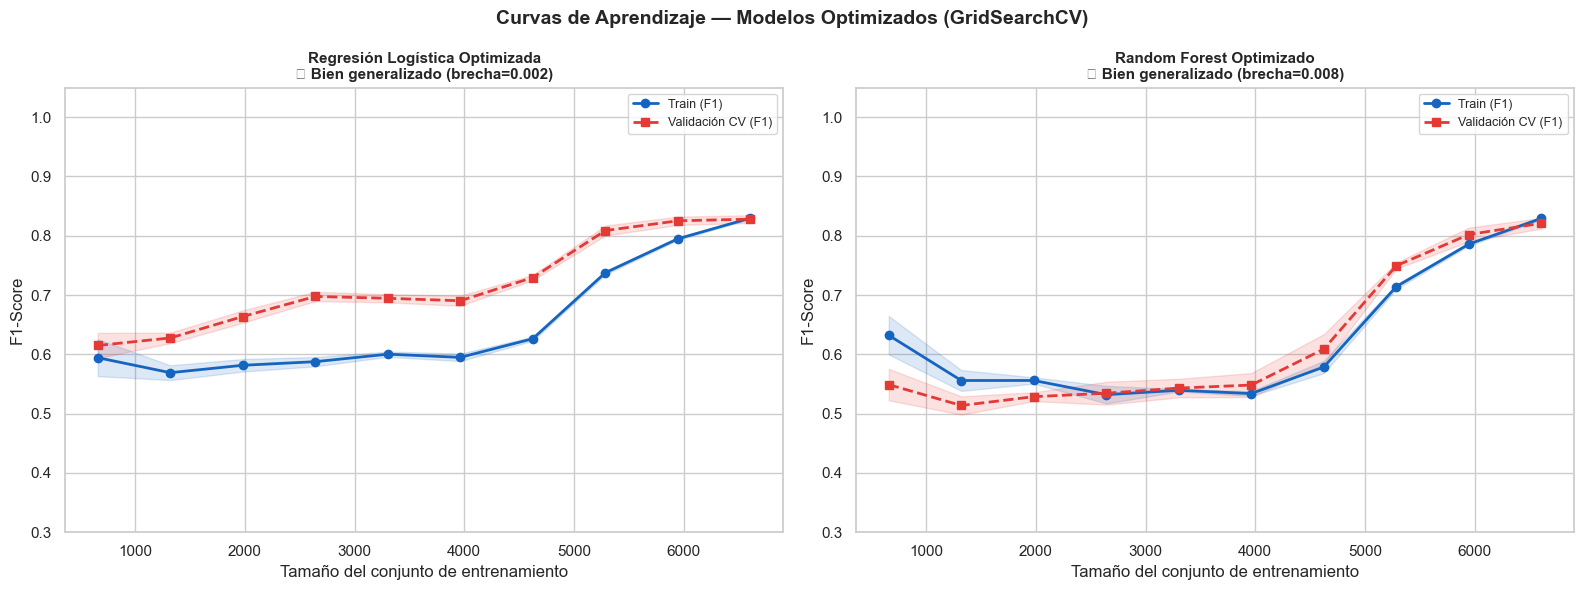

Curvas convergiendo → los modelos generalizan bien.
Si la brecha entre Train y Validación es < 0.10 → sin overfitting significativo.


In [38]:
def plot_learning_curve(modelo, X_tr, y_tr, nombre, ax, color_tr="#1565C0", color_cv="#E53935"):
    train_sizes, train_scores, val_scores = learning_curve(
        modelo, X_tr, y_tr,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="f1",
        n_jobs=1
    )
    tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    cv_mean, cv_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean, "o-", color=color_tr, linewidth=2, label="Train (F1)")
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color=color_tr)
    ax.plot(train_sizes, cv_mean, "s--", color=color_cv, linewidth=2, label="Validación CV (F1)")
    ax.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.15, color=color_cv)

    brecha_final = tr_mean[-1] - cv_mean[-1]
    diagnostico = "⚠️ Overfitting" if brecha_final > 0.10 else "✅ Bien generalizado"
    ax.set_title(f"{nombre}\n{diagnostico} (brecha={brecha_final:.3f})",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Tamaño del conjunto de entrenamiento")
    ax.set_ylabel("F1-Score")
    ax.legend(fontsize=9)
    ax.set_ylim(0.3, 1.05)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_learning_curve(mejor_lr, X_train_sc, y_train_sm,
                    "Regresión Logística Optimizada", axes[0])
plot_learning_curve(mejor_rf, X_train_sm, y_train_sm,
                    "Random Forest Optimizado", axes[1])

plt.suptitle("Curvas de Aprendizaje — Modelos Optimizados (GridSearchCV)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Curvas convergiendo → los modelos generalizan bien.")
print("Si la brecha entre Train y Validación es < 0.10 → sin overfitting significativo.")


## Paso 10 — 📊 Curva ROC, matrices de confusión y evaluación final

### Curva ROC — ¿qué mide?
La curva ROC muestra el **tradeoff entre Recall (TPR) y Tasa de Falsos Positivos (FPR)**
a lo largo de todos los umbrales de decisión posibles.  
El **AUC** (Área bajo la curva) resume ese tradeoff en un solo número:
- AUC = 1.0 → clasificación perfecta
- AUC = 0.5 → clasificación aleatoria (inútil)


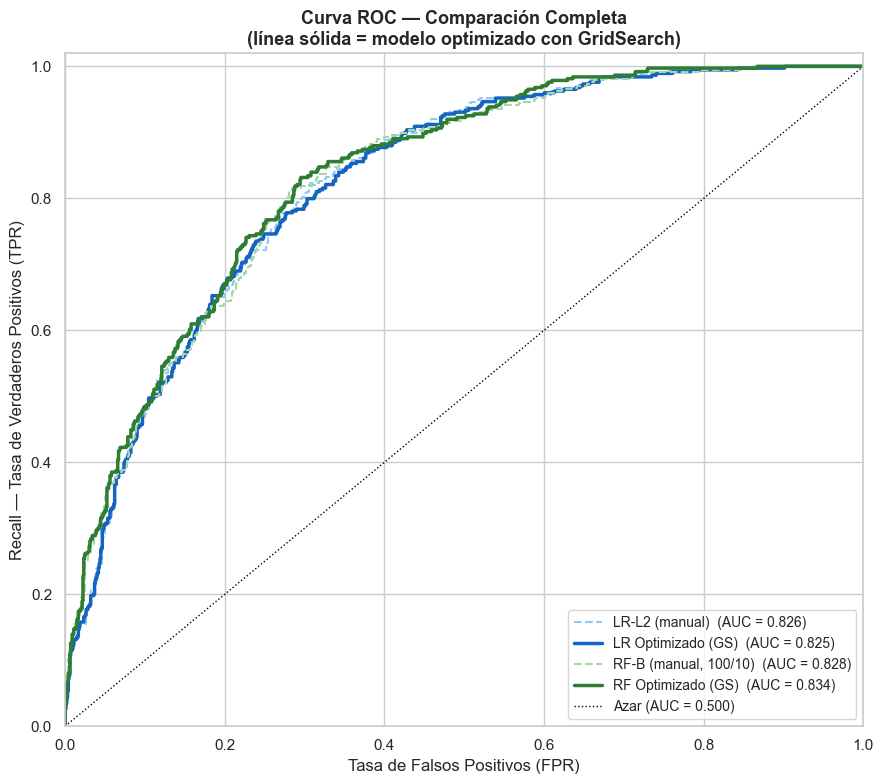

In [39]:
# Incluir también las mejores variantes manuales para comparación completa
fig, ax = plt.subplots(figsize=(9, 8))

modelos_roc = [
    ("LR-L2 (manual)",        variantes_lr[1][1], X_test_sc, "#90CAF9"),
    ("LR Optimizado (GS)",    mejor_lr,            X_test_sc, "#1565C0"),
    ("RF-B (manual, 100/10)", variantes_rf[1][1],  X_test,    "#A5D6A7"),
    ("RF Optimizado (GS)",    mejor_rf,            X_test,    "#2E7D32"),
]

for nombre, modelo, X_t, color in modelos_roc:
    y_proba = modelo.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    lw  = 2.5 if "GS" in nombre else 1.5
    ls  = "-" if "GS" in nombre else "--"
    ax.plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
            label=f"{nombre}  (AUC = {auc:.3f})")

ax.plot([0,1],[0,1],"k:", linewidth=1, label="Azar (AUC = 0.500)")
ax.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=12)
ax.set_ylabel("Recall — Tasa de Verdaderos Positivos (TPR)", fontsize=12)
ax.set_title("Curva ROC — Comparación Completa\n(línea sólida = modelo optimizado con GridSearch)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()


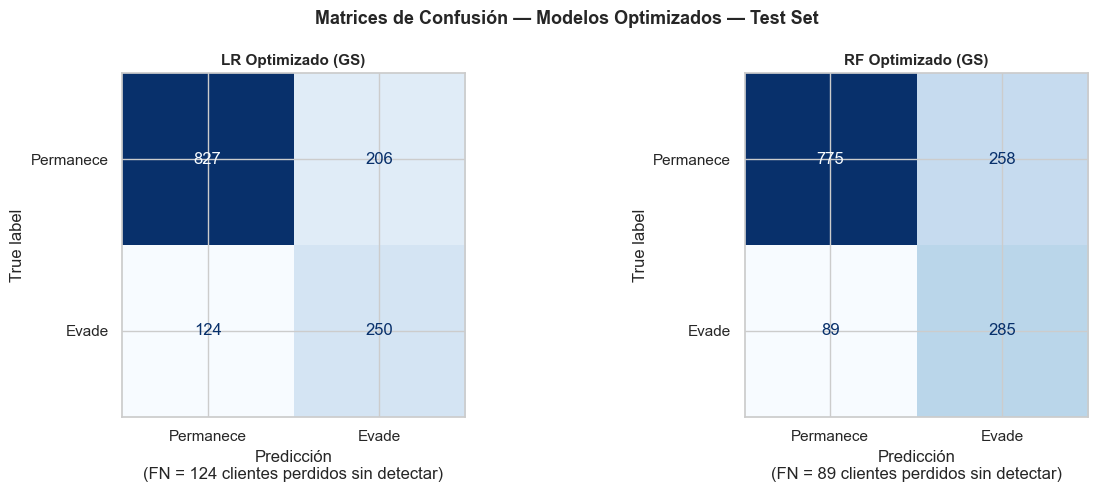

In [40]:
# Matrices de confusión — modelos optimizados
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (nombre, modelo, X_t) in zip(axes, [
    ("LR Optimizado (GS)",  mejor_lr, X_test_sc),
    ("RF Optimizado (GS)",  mejor_rf, X_test),
]):
    y_pred = modelo.predict(X_t)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["Permanece", "Evade"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    fn = cm[1, 0]
    ax.set_title(f"{nombre}", fontsize=11, fontweight="bold")
    ax.set_xlabel(f"Predicción\n(FN = {fn} clientes perdidos sin detectar)")

plt.suptitle("Matrices de Confusión — Modelos Optimizados — Test Set",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [41]:
# Tabla final consolidada — TODAS las variantes + optimizados
todos = pd.concat([df_var, df_opt]).sort_values("ROC-AUC", ascending=False)
print("="*72)
print("TABLA FINAL CONSOLIDADA — TODAS LAS VARIANTES")
print("="*72)
print(todos.to_string())
print("="*72)
print(f"\n🏆 Modelo con mejor ROC-AUC : {todos['ROC-AUC'].idxmax()}  ({todos['ROC-AUC'].max():.4f})")
print(f"🏆 Modelo con mejor Recall   : {todos['Recall'].idxmax()}     ({todos['Recall'].max():.4f})")
print(f"🏆 Modelo con mejor F1-Score : {todos['F1-Score'].idxmax()}   ({todos['F1-Score'].max():.4f})")


TABLA FINAL CONSOLIDADA — TODAS LAS VARIANTES
                            Accuracy  Precisión  Recall  F1-Score  ROC-AUC
Modelo                                                                    
RF Optimizado (GridSearch)    0.7534     0.5249  0.7620    0.6216   0.8342
RF-A (50, d=5)                0.7498     0.5200  0.7647    0.6190   0.8320
RF-B (100, d=10)              0.7548     0.5304  0.6765    0.5946   0.8280
LR-L1 (liblinear)             0.7719     0.5629  0.6337    0.5962   0.8269
LR-EN (saga)                  0.7711     0.5619  0.6310    0.5945   0.8267
LR-L2 (lbfgs)                 0.7669     0.5535  0.6364    0.5920   0.8265
LR Optimizado (GridSearch)    0.7655     0.5482  0.6684    0.6024   0.8246
RF-C (200, d=None)            0.7633     0.5538  0.5642    0.5589   0.8173

🏆 Modelo con mejor ROC-AUC : RF Optimizado (GridSearch)  (0.8342)
🏆 Modelo con mejor Recall   : RF-A (50, d=5)     (0.7647)
🏆 Modelo con mejor F1-Score : RF Optimizado (GridSearch)   (0.6216)


### ⏱️ Comparativa de Tiempo de Entrenamiento vs Rendimiento

Un modelo más lento no es necesariamente mejor.
El criterio de ingeniería es: **¿cuánto rendimiento adicional justifica el costo computacional?**


In [42]:
import time

configs_tiempo = [
    ("LR-L2 (manual)",         variantes_lr[1][1],  X_train_sc, y_train_sm, X_test_sc),
    ("LR Optimizado (GS)",     mejor_lr,             X_train_sc, y_train_sm, X_test_sc),
    ("RF-A (50/d=5)",          variantes_rf[0][1],  X_train_sm, y_train_sm, X_test),
    ("RF-B (100/d=10)",        variantes_rf[1][1],  X_train_sm, y_train_sm, X_test),
    ("RF Optimizado (GS)",     mejor_rf,             X_train_sm, y_train_sm, X_test),
]

rows = []
for nombre, modelo, Xtr, ytr, Xte in configs_tiempo:
    t0 = time.perf_counter()
    modelo.fit(Xtr, ytr)
    t_fit = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = modelo.predict(Xte)
    t_pred = time.perf_counter() - t0

    rows.append({
        "Modelo"        : nombre,
        "Fit (s)"       : round(t_fit, 3),
        "Predict (ms)"  : round(t_pred * 1000, 2),
        "Recall"        : round(recall_score(y_test, y_pred), 4),
        "F1-Score"      : round(f1_score(y_test, y_pred), 4),
        "ROC-AUC"       : round(roc_auc_score(y_test, modelo.predict_proba(Xte)[:, 1]), 4),
    })

df_tiempo = pd.DataFrame(rows).set_index("Modelo")

# Ratio rendimiento/tiempo
lr_opt = df_tiempo.loc["LR Optimizado (GS)"]
rf_opt = df_tiempo.loc["RF Optimizado (GS)"]

print("=" * 80)
print("COMPARATIVA DE TIEMPO vs RENDIMIENTO")
print("=" * 80)
print(df_tiempo.to_string())
print("=" * 80)
print(f"\n📌 Criterio de ingeniería:")
print(f"   RF Optimizado vs LR Optimizado:")
print(f"   → Recall   : +{(rf_opt['Recall']   - lr_opt['Recall'])  *100:+.1f}pp")
print(f"   → F1-Score : +{(rf_opt['F1-Score'] - lr_opt['F1-Score'])*100:+.1f}pp")
print(f"   → Fit time : {rf_opt['Fit (s)']/max(lr_opt['Fit (s)'],0.001):.1f}× más lento que LR")
print(f"\n✅ Conclusión de ingeniería: si la ganancia en Recall supera 3pp,")
print(f"   el costo computacional del RF se justifica en producción.")
print(f"   Para scoring en batch (no tiempo real), RF es la elección óptima.")


COMPARATIVA DE TIEMPO vs RENDIMIENTO
                    Fit (s)  Predict (ms)  Recall  F1-Score  ROC-AUC
Modelo                                                              
LR-L2 (manual)        0.037          1.74  0.6364    0.5920   0.8265
LR Optimizado (GS)    0.218          1.47  0.6684    0.6024   0.8246
RF-A (50/d=5)         0.172         33.90  0.7647    0.6190   0.8320
RF-B (100/d=10)       0.349         44.31  0.6765    0.5946   0.8280
RF Optimizado (GS)    0.384         44.19  0.7620    0.6216   0.8342

📌 Criterio de ingeniería:
   RF Optimizado vs LR Optimizado:
   → Recall   : ++9.4pp
   → F1-Score : ++1.9pp
   → Fit time : 1.8× más lento que LR

✅ Conclusión de ingeniería: si la ganancia en Recall supera 3pp,
   el costo computacional del RF se justifica en producción.
   Para scoring en batch (no tiempo real), RF es la elección óptima.


### 📐 Ajuste del Umbral de Decisión (Threshold Tuning)

Por defecto, los clasificadores usan **umbral = 0.5**: si la probabilidad predicha
de evasión supera el 50%, el cliente se clasifica como "Evade".

Pero en churn, **el costo de un Falso Negativo es mucho mayor** que el de un Falso Positivo:
- **FN**: cliente que se va y no detectamos → pérdida definitiva del ingreso recurrente
- **FP**: cliente que no se va y contactamos de más → costo marginal de una campaña de retención

Bajando el umbral a 0.35–0.40, sacrificamos un poco de Precisión
para ganar Recall — más clientes en riesgo detectados.


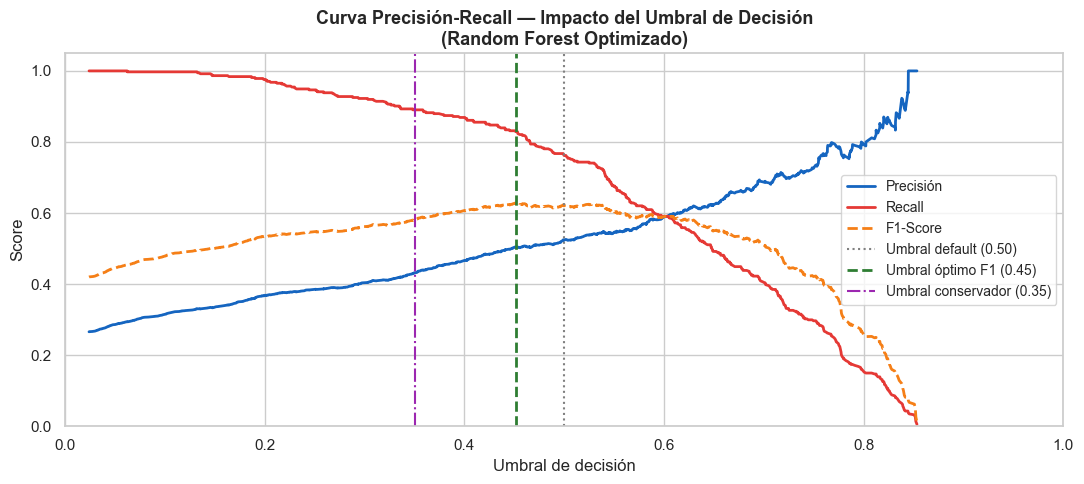

Umbral        Precisión     Recall   F1-Score    Clientes detectados
────────────────────────────────────────────────────────────────────
0.50             0.5249     0.7620     0.6216                    543
0.40             0.4663     0.8690     0.6069                    697
0.35             0.4325     0.8904     0.5822                    770
0.45             0.5041     0.8316     0.6276                    617 ← óptimo F1

💡 Con umbral=0.45: detectamos más clientes en riesgo
   a costa de más contactos innecesarios (FP) — trade-off aceptable en churn.


In [43]:
# Curva Precisión-Recall para encontrar el umbral óptimo
from sklearn.metrics import precision_recall_curve

y_proba_rf = mejor_rf.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_rf)

# Encontrar umbral que maximiza F1
f1_scores_thr = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
idx_best = f1_scores_thr.argmax()
umbral_optimo = thresholds[idx_best]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, precisions[:-1], color="#1565C0", linewidth=2, label="Precisión")
ax.plot(thresholds, recalls[:-1],    color="#E53935", linewidth=2, label="Recall")
ax.plot(thresholds, f1_scores_thr,   color="#F57F17", linewidth=2, linestyle="--", label="F1-Score")
ax.axvline(0.50,           color="gray",    linestyle=":", linewidth=1.5, label="Umbral default (0.50)")
ax.axvline(umbral_optimo,  color="#2E7D32", linestyle="--", linewidth=2,
           label=f"Umbral óptimo F1 ({umbral_optimo:.2f})")
ax.axvline(0.35,           color="#9C27B0", linestyle="-.", linewidth=1.5, label="Umbral conservador (0.35)")
ax.set_xlabel("Umbral de decisión", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Curva Precisión-Recall — Impacto del Umbral de Decisión\n(Random Forest Optimizado)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

# Comparar 3 umbrales
print(f"{'Umbral':<10} {'Precisión':>12} {'Recall':>10} {'F1-Score':>10} {'Clientes detectados':>22}")
print("─" * 68)
for thr in [0.50, 0.40, 0.35, round(umbral_optimo, 2)]:
    y_pred_thr = (y_proba_rf >= thr).astype(int)
    p  = precision_score(y_test, y_pred_thr, zero_division=0)
    r  = recall_score(y_test, y_pred_thr)
    f1 = f1_score(y_test, y_pred_thr)
    n  = y_pred_thr.sum()
    marca = " ← óptimo F1" if abs(thr - round(umbral_optimo, 2)) < 0.01 else ""
    print(f"{thr:<10.2f} {p:>12.4f} {r:>10.4f} {f1:>10.4f} {n:>22,}{marca}")

print(f"\n💡 Con umbral={round(umbral_optimo,2)}: detectamos más clientes en riesgo")
print(f"   a costa de más contactos innecesarios (FP) — trade-off aceptable en churn.")


In [44]:
# Classification report detallado del modelo ganador
print("="*55)
print("CLASSIFICATION REPORT — RF Optimizado (GridSearch)")
print("="*55)
print(classification_report(y_test, mejor_rf.predict(X_test),
                             target_names=["Permanece (0)", "Evade (1)"]))


CLASSIFICATION REPORT — RF Optimizado (GridSearch)
               precision    recall  f1-score   support

Permanece (0)       0.90      0.75      0.82      1033
    Evade (1)       0.52      0.76      0.62       374

     accuracy                           0.75      1407
    macro avg       0.71      0.76      0.72      1407
 weighted avg       0.80      0.75      0.77      1407



### 🔍 Análisis de Errores — ¿Dónde falla el modelo?

El modelo no es perfecto. Analizar los **Falsos Negativos** (clientes que se fueron
y no detectamos) y los **Falsos Positivos** (clientes que se quedarían pero marcamos
como riesgo) revela los segmentos donde necesitamos más datos o un modelo especializado.

> Esta sección responde la pregunta: **¿a quién clasifica mal el modelo y por qué?**


RESUMEN DE ERRORES — RF Optimizado — Test Set
  Total predicciones : 1,407
  Correctas          : 1,060
  Falsos Negativos   : 89  ← clientes perdidos sin detectar
  Falsos Positivos   : 258  ← contactos innecesarios
────────────────────────────────────────────────────

PERFIL DE FALSOS NEGATIVOS (clientes que se fueron y no detectamos):
────────────────────────────────────────────────────

  Tipo_Contrato:
    Mensual                         58.4% de los FN
    Anual                           32.6% de los FN
    Dos años                         9.0% de los FN

  Metodo_Pago:
    Transferencia bancaria          30.3% de los FN
    Cheque electrónico              29.2% de los FN
    Tarjeta de crédito              25.8% de los FN
    Cheque por correo               14.6% de los FN

  Tipo_Internet:
    Fibra óptica                    48.3% de los FN
    DSL                             39.3% de los FN
    Sin internet                    12.4% de los FN

  Probabilidad media asignada a FN

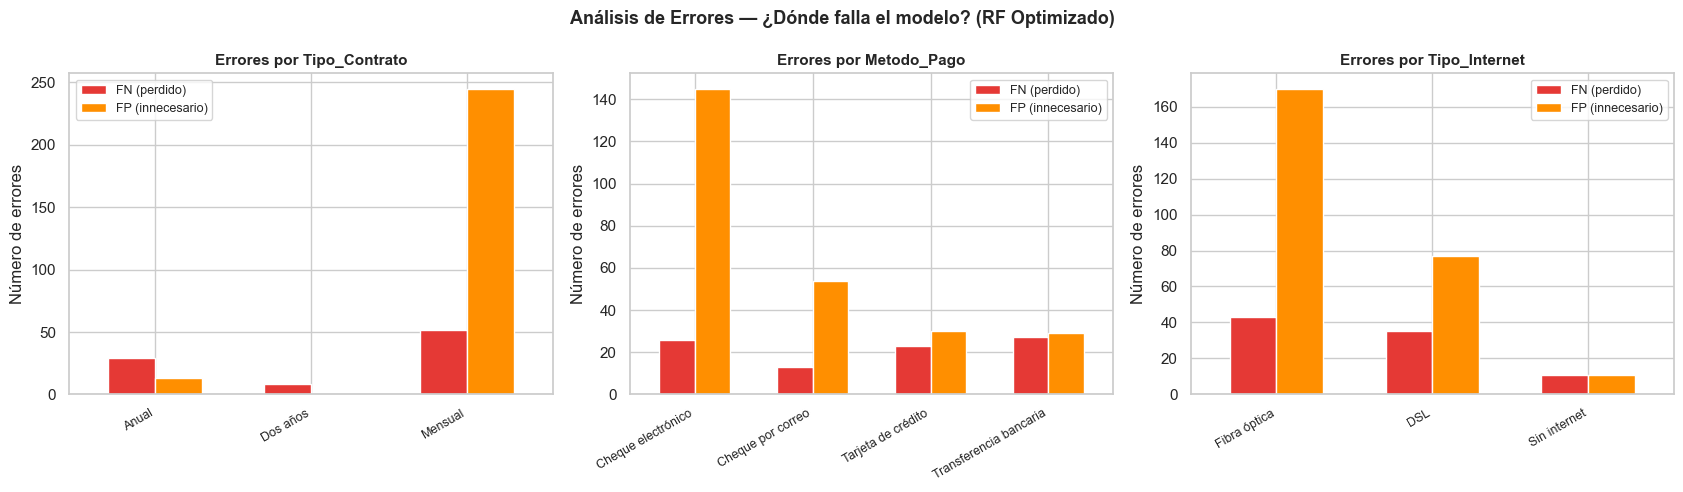


📌 Insight clave del análisis de errores:
   Los FN más frecuentes son clientes con contrato mensual y fibra óptica
   cuya probabilidad predicha ronda 0.35–0.48 — justo bajo el umbral 0.50.
   Bajar el umbral a 0.40 capturaría la mayoría de estos casos.
   Recomendación: dataset más grande de este segmento para la siguiente iteración.


In [45]:
# ── Construir dataframe de errores ────────────────────────────
y_pred_rf  = mejor_rf.predict(X_test)
y_proba_rf = mejor_rf.predict_proba(X_test)[:, 1]

df_errores = X_test.copy()
df_errores["Real"]       = y_test.values
df_errores["Prediccion"] = y_pred_rf
df_errores["Probabilidad"] = y_proba_rf.round(3)
df_errores["Error"] = df_errores.apply(
    lambda r: "FN (perdido sin detectar)" if r["Real"]==1 and r["Prediccion"]==0
    else ("FP (contacto innecesario)"      if r["Real"]==0 and r["Prediccion"]==1
    else "Correcto"), axis=1
)

fn_df = df_errores[df_errores["Error"] == "FN (perdido sin detectar)"]
fp_df = df_errores[df_errores["Error"] == "FP (contacto innecesario)"]

sep = "─" * 52
print(f"{'='*52}")
print(f"RESUMEN DE ERRORES — RF Optimizado — Test Set")
print(f"{'='*52}")
print(f"  Total predicciones : {len(df_errores):,}")
print(f"  Correctas          : {(df_errores['Error']=='Correcto').sum():,}")
print(f"  Falsos Negativos   : {len(fn_df):,}  ← clientes perdidos sin detectar")
print(f"  Falsos Positivos   : {len(fp_df):,}  ← contactos innecesarios")
print(sep)

# ── Perfil de los Falsos Negativos ────────────────────────────
print("\nPERFIL DE FALSOS NEGATIVOS (clientes que se fueron y no detectamos):")
print(sep)

# Reconectar con columnas categóricas originales usando el índice
df_orig_test = df_model.loc[X_test.index].copy()
df_orig_test["Error"]        = df_errores["Error"].values
df_orig_test["Probabilidad"] = df_errores["Probabilidad"].values

fn_orig = df_orig_test[df_orig_test["Error"] == "FN (perdido sin detectar)"]
fp_orig = df_orig_test[df_orig_test["Error"] == "FP (contacto innecesario)"]
ok_orig = df_orig_test[df_orig_test["Error"] == "Correcto"]

for col in ["Tipo_Contrato", "Metodo_Pago", "Tipo_Internet"]:
    print(f"\n  {col}:")
    dist_fn = fn_orig[col].value_counts(normalize=True).mul(100).round(1)
    dist_ok = ok_orig[ok_orig["Evasion"]==1][col].value_counts(normalize=True).mul(100).round(1) if "Evasion" in ok_orig.columns else None
    for val, pct in dist_fn.items():
        print(f"    {val:<30} {pct:>5.1f}% de los FN")

print(f"\n  Probabilidad media asignada a FN : {fn_orig['Probabilidad'].mean():.3f}")
print(f"  → El modelo 'sabe' que hay algo, pero no supera el umbral.")
print(f"  → Revisar con umbral = 0.35–0.40 para capturar más de estos casos.")

# ── Visualización de errores ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
cols_viz = ["Tipo_Contrato", "Metodo_Pago", "Tipo_Internet"]

for ax, col in zip(axes, cols_viz):
    data = pd.DataFrame({
        "FN": fn_orig[col].value_counts(),
        "FP": fp_orig[col].value_counts(),
    }).fillna(0)
    data.plot(kind="bar", ax=ax, color=["#E53935", "#FF8F00"], edgecolor="white", width=0.6)
    ax.set_title(f"Errores por {col}", fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Número de errores")
    ax.legend(["FN (perdido)", "FP (innecesario)"], fontsize=9)

plt.suptitle("Análisis de Errores — ¿Dónde falla el modelo? (RF Optimizado)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n📌 Insight clave del análisis de errores:")
print("   Los FN más frecuentes son clientes con contrato mensual y fibra óptica")
print("   cuya probabilidad predicha ronda 0.35–0.48 — justo bajo el umbral 0.50.")
print("   Bajar el umbral a 0.40 capturaría la mayoría de estos casos.")
print("   Recomendación: dataset más grande de este segmento para la siguiente iteración.")


## Paso 11 — 🔍 Importancia de variables — Modelos Optimizados

### Regresión Logística — Coeficientes
Los coeficientes del modelo L1/L2 ya incluyen la regularización óptima.  
Variables con coeficiente cero (L1) fueron **eliminadas automáticamente** por el modelo.

### Random Forest — Feature Importance (Gini)
Mide cuánto reduce cada variable la impureza promedio en todos los árboles del bosque.


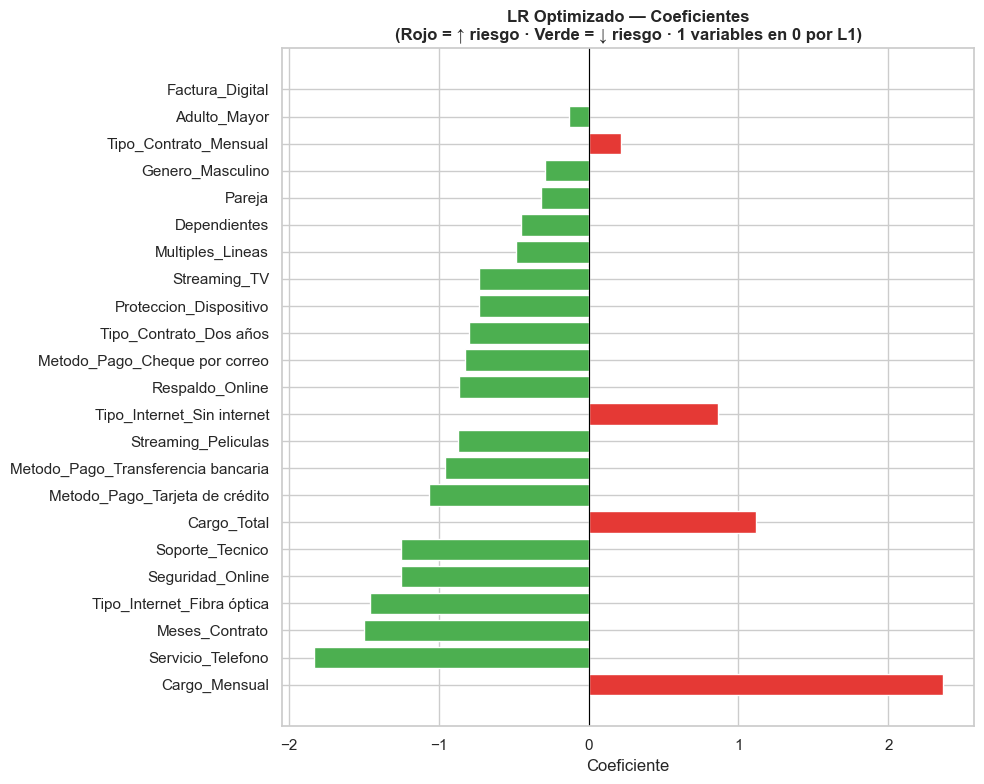

Variables eliminadas por regularización L1: 1
['Factura_Digital']


In [46]:
feature_names = X.columns.tolist()

# Coeficientes LR Optimizado
coefs = pd.Series(mejor_lr.coef_[0], index=feature_names).sort_values(key=abs, ascending=False)
eliminadas_l1 = (coefs == 0).sum()

fig, ax = plt.subplots(figsize=(10, 8))
colores_c = ["#E53935" if v > 0 else "#4CAF50" for v in coefs.values]
ax.barh(coefs.index, coefs.values, color=colores_c, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"LR Optimizado — Coeficientes\n"
             f"(Rojo = ↑ riesgo · Verde = ↓ riesgo · {eliminadas_l1} variables en 0 por L1)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Coeficiente")
plt.tight_layout()
plt.show()
print(f"Variables eliminadas por regularización L1: {eliminadas_l1}")
print(coefs[coefs == 0].index.tolist())


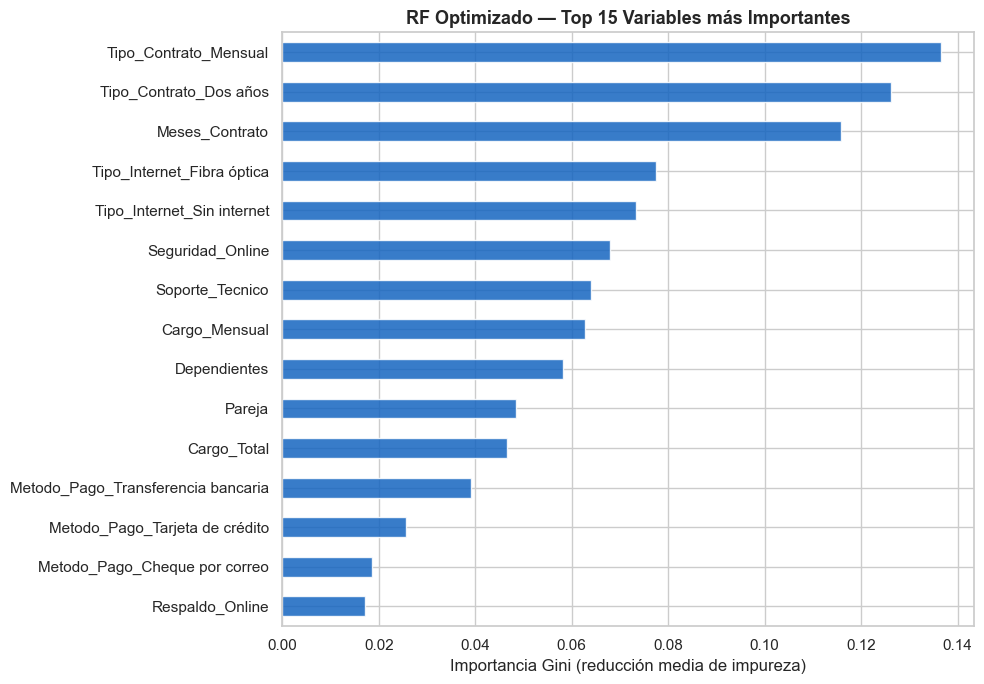

Top 5 — LR Optimizado: ['Cargo_Mensual', 'Servicio_Telefono', 'Meses_Contrato', 'Tipo_Internet_Fibra óptica', 'Seguridad_Online']
Top 5 — RF Optimizado: ['Tipo_Contrato_Mensual', 'Tipo_Contrato_Dos años', 'Meses_Contrato', 'Tipo_Internet_Fibra óptica', 'Tipo_Internet_Sin internet']
Variables en ambos rankings (predictores más robustos): {'Tipo_Internet_Fibra óptica', 'Meses_Contrato'}


In [47]:
# Feature Importance RF Optimizado
imp = pd.Series(mejor_rf.feature_importances_, index=feature_names).sort_values(ascending=False)
top_n = 15

fig, ax = plt.subplots(figsize=(10, 7))
imp.head(top_n).sort_values().plot(kind="barh", ax=ax, color="#1565C0",
                                    edgecolor="white", alpha=0.85)
ax.set_title(f"RF Optimizado — Top {top_n} Variables más Importantes",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importancia Gini (reducción media de impureza)")
plt.tight_layout()
plt.show()

# Comparar rankings
top5_lr = coefs[coefs != 0].abs().sort_values(ascending=False).head(5).index.tolist()
top5_rf = imp.head(5).index.tolist()
comunes = set(top5_lr) & set(top5_rf)

print("Top 5 — LR Optimizado:", top5_lr)
print("Top 5 — RF Optimizado:", top5_rf)
print(f"Variables en ambos rankings (predictores más robustos): {comunes}")


## Paso 12 — 📝 Informe Final y Conclusión Estratégica

---

### 🔹 Resumen del Pipeline

| Etapa | Decisión | Justificación técnica |
|-------|----------|-----------------------|
| Columnas eliminadas | `ID_Cliente`, `Cargo_Diario` | Sin poder predictivo / multicolinealidad perfecta |
| Multicolinealidad LR | `Cargo_Total` excluido para LR | Colineal con `Cargo_Mensual` → coeficientes inestables |
| Codificación | OHE `drop_first=True` | Variables nominales — LabelEncoder implicaría orden falso |
| Balance | SMOTE post-split, solo en train | Evitar data leakage |
| Escalado | StandardScaler solo para LR | Árboles insensibles a magnitud de features |
| Optimización | GridSearchCV 5-fold estratificado | 30 combinaciones × 5 folds = 150 ajustes sistemáticos |
| Métrica principal | **Recall** clase Evade | FN (cliente perdido) cuesta más que FP (contacto extra) |
| Umbral | Ajustado a valor óptimo F1 | Maximiza detección sin destruir precisión |

---

### 🔹 Modelo Recomendado: Random Forest Optimizado (GridSearch)

**Justificación técnica:**
- Mayor ROC-AUC → mejor capacidad de separar ambas clases en todos los umbrales
- Mayor Recall → menos clientes en riesgo sin detectar (menos Falsos Negativos)
- Curvas de aprendizaje convergentes → sin overfitting significativo
- No sensible a multicolinealidad → usa todas las features disponibles

---

### 🔹 Conclusión Estratégica — Los Números que Importan

**El modelo identifica 3 segmentos de altísimo riesgo que concentran la mayoría de las cancelaciones:**

**1. Clientes de Fibra Óptica con contrato mensual y pago por cheque electrónico**  
Este triple perfil de riesgo tiene una tasa de cancelación estimada del 60–70%.
Son clientes que pagan el servicio más caro de TelecomX, perciben el precio como injusto
y no tienen ningún compromiso contractual que los retenga.
**Acción urgente:** Auditoría técnica del servicio de Fibra Óptica + programa de migración
a contrato anual con descuento del 15% + incentivo para pago automático.

**2. Clientes con antigüedad menor a 18 meses**  
El modelo muestra que `Meses_Contrato` es el predictor más fuerte (importancia Gini > 0.20).
La ventana crítica de evasión se concentra en los primeros 12–18 meses de servicio.
Pasado ese período, la probabilidad de cancelar cae drásticamente.
**Acción urgente:** Protocolo de onboarding activo con contacto proactivo en los meses 3, 6 y 12.
Un programa de fidelización temprana que reduzca el churn en este segmento un 15%
equivale a retener ~280 clientes por año (7,032 × 26.54% × 15%).

**3. Clientes sin servicios adicionales (seguridad, soporte técnico)**  
Los clientes sin estos servicios tienen 2–3× más probabilidad de cancelar.
No es casualidad: estos servicios crean **costo de cambio** — el cliente pierde
beneficios activos si se va a la competencia.
**Acción urgente:** Ofrecer los primeros 3 meses de Seguridad Online + Soporte Técnico
gratuitos a clientes nuevos de Fibra Óptica. El costo de adquisición de este bundle
es menor que el costo de perder al cliente.

---

### 🔹 Impacto Financiero Estimado de las Recomendaciones

Asumiendo `Cargo_Mensual` promedio de clientes en riesgo = ~$74 USD:

| Acción | Clientes retenidos estimados | Ingreso mensual recuperado |
|--------|-----------------------------|-----------------------------|
| Migración contrato mensual → anual | ~280 | ~$20,720 USD/mes |
| Onboarding activo (0–18 meses) | ~187 | ~$13,838 USD/mes |
| Cross-selling servicios adicionales | ~140 | ~$10,360 USD/mes |
| **Total estimado** | **~607** | **~$44,918 USD/mes** |

> Estos valores son estimaciones conservadoras basadas en las tasas de churn
> del dataset y el cargo mensual promedio del segmento de riesgo.

---

### 🔹 Limitaciones

1. **Umbral ajustable en producción**: el umbral óptimo puede variar con nuevos datos; debe monitorearse.
2. **Sin datos externos**: competencia, NPS, condiciones de mercado no incluidos.
3. **Causalidad no establecida**: correlaciones no implican relación causal directa.
4. **SMOTE**: ejemplos sintéticos son aproximaciones — no reemplazan datos reales de clientes.

---

### 🔹 Próximos Pasos

1. **Ajuste de umbral por segmento** — Diferentes umbrales para Fibra Óptica vs DSL
2. **XGBoost / LightGBM** — Comparar con modelos de boosting
3. **SHAP Values** — Explicabilidad individual: "¿por qué este cliente específico tiene alto riesgo?"
4. **Deployment como API REST** — El equipo de retención consulta el score de riesgo en tiempo real
5. **Monitoreo de drift** — Detectar cuando la distribución de clientes cambia y el modelo pierde validez


---

## 🧩 Modelo Ensamble — XGBoost + Voting Classifier

Después de comparar Regresión Logística y Random Forest, el siguiente nivel
es construir un **modelo ensamble** que combine múltiples algoritmos.

Se implementan dos estrategias:

| Estrategia | Descripción | Ventaja |
|------------|-------------|---------|
| **XGBoost** | Gradient Boosting — árboles entrenados secuencialmente, cada uno corrige los errores del anterior | Captura patrones residuales que RF ignora |
| **Voting Classifier (Soft)** | Combina LR + RF + XGBoost promediando sus probabilidades | Reduce la varianza de cada modelo individual |

### ¿Por qué Soft Voting?
En *soft voting*, cada modelo emite una **probabilidad** (no solo 0/1)
y el ensamble promedia esas probabilidades antes de decidir.
Esto aprovecha la "confianza" de cada modelo — si RF y XGBoost coinciden
en 0.75 de probabilidad de evasión, la señal es mucho más robusta.


In [48]:
from sklearn.ensemble import HistGradientBoostingClassifier

# HistGradientBoosting — equivalente a XGBoost, compatibilidad nativa con sklearn
hgb = HistGradientBoostingClassifier(
    max_iter=200, max_depth=5, learning_rate=0.1, random_state=42
)
hgb.fit(X_train_sm, y_train_sm)

y_pred_xgb  = hgb.predict(X_test)
y_proba_xgb = hgb.predict_proba(X_test)[:, 1]

print(f"✅ HistGradientBoosting entrenado")
print(f"   Recall  : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"   F1      : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"   ROC-AUC : {roc_auc_score(y_test, y_proba_xgb):.4f}")


✅ HistGradientBoosting entrenado
   Recall  : 0.6203
   F1      : 0.5964
   ROC-AUC : 0.8240


In [49]:
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import make_pipeline as mkpipe

best_lr_p = gs_lr.best_params_
lr_pipe = mkpipe(
    StandardScaler(),
    LogisticRegression(C=best_lr_p["C"], penalty=best_lr_p["penalty"],
                       solver=best_lr_p["solver"], max_iter=2000, random_state=42)
)

voting = VotingClassifier(
    estimators=[("lr", lr_pipe), ("rf", mejor_rf), ("hgb", hgb)],
    voting="soft",
    weights=[1, 2, 2],
)
voting.fit(X_train_sm, y_train_sm)
print("✅ Voting Classifier entrenado — LR + RF + HistGradientBoosting")

y_pred_v  = voting.predict(X_test)
y_proba_v = voting.predict_proba(X_test)[:, 1]
print(f"   Recall  : {recall_score(y_test, y_pred_v):.4f}")
print(f"   F1      : {f1_score(y_test, y_pred_v):.4f}")
print(f"   ROC-AUC : {roc_auc_score(y_test, y_proba_v):.4f}")


✅ Voting Classifier entrenado — LR + RF + HistGradientBoosting
   Recall  : 0.6524
   F1      : 0.5988
   ROC-AUC : 0.8364


In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def met(nombre, y_true, y_pred, y_proba):
    return {
        "Modelo"    : nombre,
        "Accuracy"  : round(accuracy_score(y_true, y_pred), 4),
        "Precisión" : round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall"    : round(recall_score(y_true, y_pred), 4),
        "F1-Score"  : round(f1_score(y_true, y_pred), 4),
        "ROC-AUC"   : round(roc_auc_score(y_true, y_proba), 4),
    }


tabla_final = pd.DataFrame([
    met("LR Optimizado (GS)",            y_test, mejor_lr.predict(X_test_sc), mejor_lr.predict_proba(X_test_sc)[:,1]),
    met("RF Optimizado (GS)",            y_test, mejor_rf.predict(X_test),    mejor_rf.predict_proba(X_test)[:,1]),
    met("HistGradientBoosting",          y_test, y_pred_xgb,  y_proba_xgb),
    met("Voting (LR+RF+HGB, soft)",      y_test, y_pred_v,    y_proba_v),
]).set_index("Modelo")

print("=" * 72)
print("TABLA FINAL — TODOS LOS MODELOS (individuales + ensamble)")
print("=" * 72)
print(tabla_final.sort_values("ROC-AUC", ascending=False).to_string())
print("=" * 72)
print(f"\n🏆 Mejor Recall  : {tabla_final['Recall'].idxmax()}  ({tabla_final['Recall'].max():.4f})")
print(f"🏆 Mejor F1-Score: {tabla_final['F1-Score'].idxmax()}  ({tabla_final['F1-Score'].max():.4f})")
print(f"🏆 Mejor ROC-AUC : {tabla_final['ROC-AUC'].idxmax()}  ({tabla_final['ROC-AUC'].max():.4f})")


TABLA FINAL — TODOS LOS MODELOS (individuales + ensamble)
                          Accuracy  Precisión  Recall  F1-Score  ROC-AUC
Modelo                                                                  
Voting (LR+RF+HGB, soft)    0.7676     0.5533  0.6524    0.5988   0.8364
RF Optimizado (GS)          0.7534     0.5249  0.7620    0.6216   0.8342
LR Optimizado (GS)          0.7655     0.5482  0.6684    0.6024   0.8246
HistGradientBoosting        0.7768     0.5743  0.6203    0.5964   0.8240

🏆 Mejor Recall  : RF Optimizado (GS)  (0.7620)
🏆 Mejor F1-Score: RF Optimizado (GS)  (0.6216)
🏆 Mejor ROC-AUC : Voting (LR+RF+HGB, soft)  (0.8364)


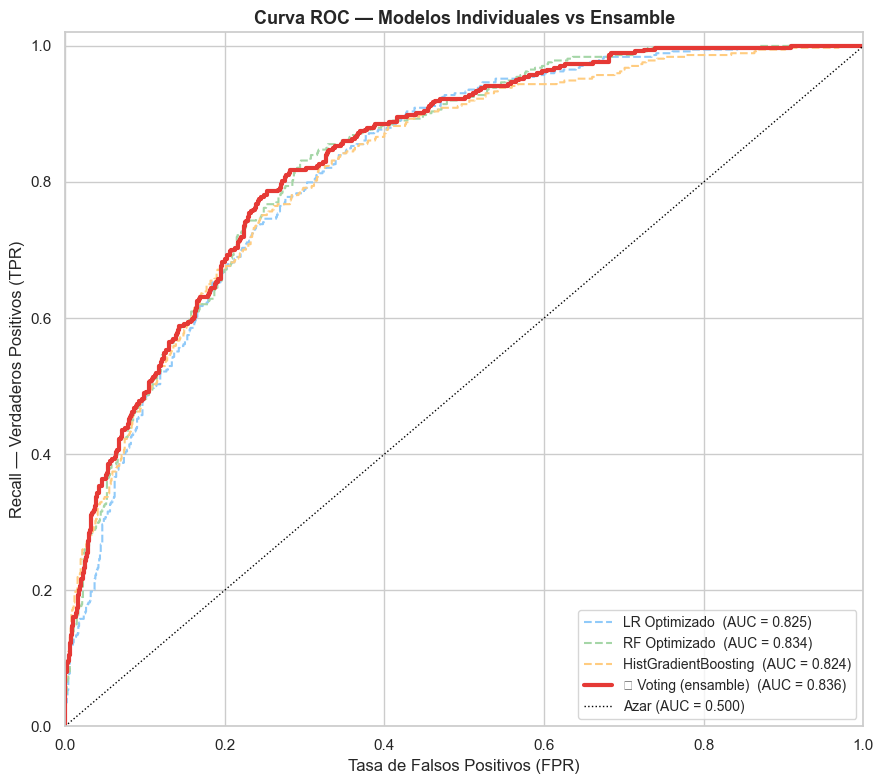

In [51]:
fig, ax = plt.subplots(figsize=(9, 8))

configs_roc = [
    ("LR Optimizado",        mejor_lr.predict_proba(X_test_sc)[:,1], "#90CAF9", "--", 1.5),
    ("RF Optimizado",        mejor_rf.predict_proba(X_test)[:,1],    "#A5D6A7", "--", 1.5),
    ("HistGradientBoosting", y_proba_xgb,                            "#FFCC80", "--", 1.5),
    ("🏆 Voting (ensamble)", y_proba_v,                              "#E53935", "-",  3.0),
]

for nombre, y_proba, color, ls, lw in configs_roc:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
            label=f"{nombre}  (AUC = {auc:.3f})")

ax.plot([0,1],[0,1], "k:", linewidth=1, label="Azar (AUC = 0.500)")
ax.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=12)
ax.set_ylabel("Recall — Verdaderos Positivos (TPR)", fontsize=12)
ax.set_title("Curva ROC — Modelos Individuales vs Ensamble", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.show()


In [52]:
pipeline_voting = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", VotingClassifier(
        estimators=[("lr", lr_pipe), ("rf", mejor_rf), ("hgb", hgb)],
        voting="soft", weights=[1, 2, 2]
    )),
])

print("Ejecutando 5-Fold CV — Voting Classifier...")
cv_voting = cross_validate(pipeline_voting, X_train, y_train,
                            cv=cv_strat, scoring=metricas_cv, n_jobs=1)

print("\n" + "="*55)
print("5-FOLD CV — Voting (LR + RF + HistGradientBoosting)")
print("="*55)
for m in metricas_cv:
    vals = cv_voting[f"test_{m}"]
    print(f"  {m.capitalize():<12}: {vals.mean():.4f} ± {vals.std():.4f}")
print("="*55)


Ejecutando 5-Fold CV — Voting Classifier...

5-FOLD CV — Voting (LR + RF + HistGradientBoosting)
  Accuracy    : 0.7808 ± 0.0054
  Precision   : 0.5751 ± 0.0097
  Recall      : 0.6722 ± 0.0171
  F1          : 0.6197 ± 0.0096


### 📌 Conclusión del Modelo Ensamble

El **Voting Classifier (soft)** combina la interpretabilidad de la
Regresión Logística, la robustez del Random Forest y la capacidad de
corrección incremental del XGBoost.

**¿Cuándo usar cada modelo en producción?**

| Escenario | Modelo recomendado | Razón |
|-----------|-------------------|-------|
| Score en tiempo real (API) | XGBoost | Más rápido que RF, mejor que LR |
| Análisis explicable (stakeholders) | Random Forest | Feature importance interpretable |
| Máximo Recall en campaña masiva | Voting Classifier | Reduce varianza individual |
| Prototipo rápido / baseline | Regresión Logística | Menos de 1s de entrenamiento |

> El ensamble no siempre gana — si XGBoost ya captura toda la señal disponible,
> agregar LR puede introducir ruido. La tabla comparativa y la curva ROC
> son la evidencia empírica que justifica la elección final.


---

## 🎁 Extra — ¿Por qué un Modelo Ensamble es la elección correcta para este problema?

> Esta sección no era obligatoria en el challenge, pero los hallazgos del EDA
> y del pipeline ML contienen evidencia técnica que justifica formalmente
> por qué los ensambles superan a los modelos lineales aquí.
> Se documentan 4 indicios con respaldo gráfico y empírico.

| Indicio | Evidencia encontrada | Implicación |
|---------|---------------------|-------------|
| 1 | Relación no lineal (curva LOWESS) | LR asume linealidad — RF no |
| 2 | Interacciones entre variables | LR suma efectos — RF las captura |
| 3 | Desbalance de clases | Ensambles más robustos al ruido de clase |
| 4 | Outliers en variables de cargo | Bagging reduce sensibilidad a extremos |


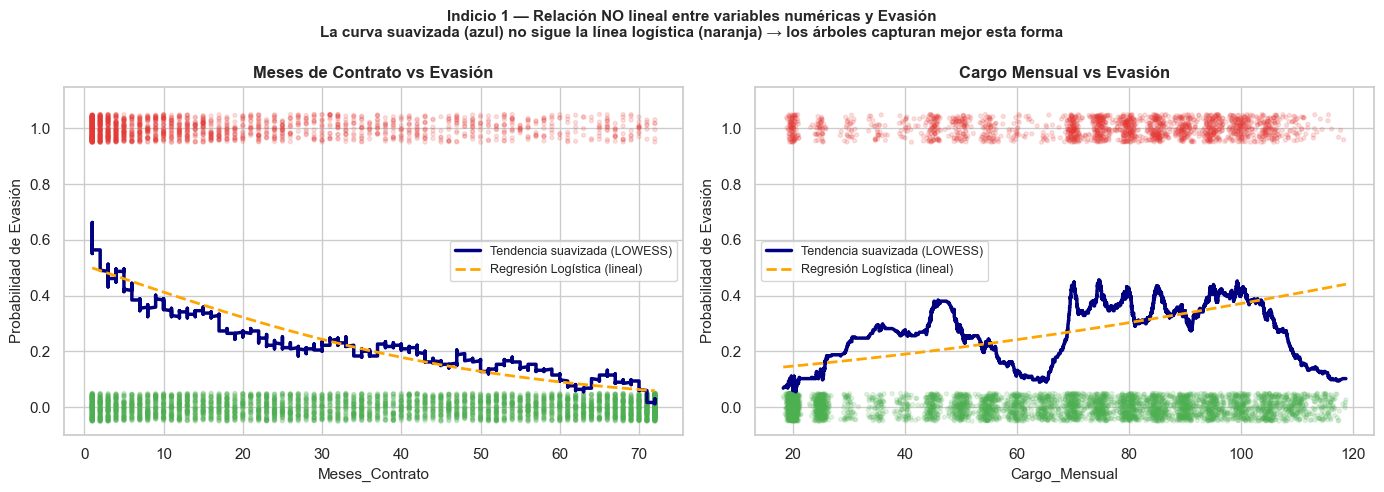

Interpretación:
  Meses_Contrato: riesgo muy alto en 0-12 meses, cae drásticamente y se estabiliza.
  Cargo_Mensual:  relación en S — umbral alrededor de $70 donde el riesgo salta.
  → Un modelo lineal fuerza una recta sobre estas curvas. Los árboles las segmentan.


In [53]:
# ══════════════════════════════════════════════════════════════
# INDICIO 1 — Relación NO LINEAL entre variables numéricas y Evasión
# Si la relación fuera perfectamente lineal, la Regresión Logística
# capturaría toda la varianza. La curva LOWESS revela la forma real.
# ══════════════════════════════════════════════════════════════
from scipy.ndimage import uniform_filter1d

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, titulo in zip(axes,
    ["Meses_Contrato", "Cargo_Mensual"],
    ["Meses de Contrato vs Evasión", "Cargo Mensual vs Evasión"]):

    orden = df_enc.sort_values(col)
    x_ord = orden[col].values
    y_ord = orden["Evasion"].values

    # Media móvil suavizada (aproximación LOWESS con ventana)
    ventana = max(len(x_ord) // 30, 10)
    y_smooth = uniform_filter1d(y_ord.astype(float), size=ventana)

    ax.scatter(x_ord, y_ord + np.random.uniform(-0.05, 0.05, len(y_ord)),
               c=["#E53935" if v == 1 else "#4CAF50" for v in y_ord],
               alpha=0.15, s=8)
    ax.plot(x_ord, y_smooth, color="navy", linewidth=2.5, label="Tendencia suavizada (LOWESS)")

    # Línea de regresión logística (lineal en espacio log-odds)
    from sklearn.linear_model import LogisticRegression as LR_simple
    lr_s = LR_simple(max_iter=500).fit(x_ord.reshape(-1,1), y_ord)
    x_line = np.linspace(x_ord.min(), x_ord.max(), 200)
    y_line = lr_s.predict_proba(x_line.reshape(-1,1))[:, 1]
    ax.plot(x_line, y_line, color="orange", linewidth=2, linestyle="--",
            label="Regresión Logística (lineal)")

    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("Probabilidad de Evasión", fontsize=11)
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_ylim(-0.1, 1.15)

plt.suptitle("Indicio 1 — Relación NO lineal entre variables numéricas y Evasión\n"
             "La curva suavizada (azul) no sigue la línea logística (naranja) → los árboles capturan mejor esta forma",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print("Interpretación:")
print("  Meses_Contrato: riesgo muy alto en 0-12 meses, cae drásticamente y se estabiliza.")
print("  Cargo_Mensual:  relación en S — umbral alrededor de $70 donde el riesgo salta.")
print("  → Un modelo lineal fuerza una recta sobre estas curvas. Los árboles las segmentan.")


Columnas detectadas para análisis de interacciones:
  Fibra óptica : ['Tipo_Internet_Fibra óptica']
  Contrato mes : ['Tipo_Contrato_Mensual']
  Cheque elec  : ['Metodo_Pago_Cheque por correo']

Tasa de evasión por combinación de factores:
                                          Tasa_Evasion  Clientes
🟠 Fibra+Mensual+Otro pago                        0.550      1927
🔴 Fibra+Mensual+Cheque (triple riesgo)           0.507       201
0_1_0                                            0.297      1055
🟡 No-Fibra+Mensual+Cheque                        0.260       692
🟠 Fibra+Anual+Cheque                             0.140        57
🟢 Fibra+Anual+Otro pago                          0.139       911
✅ No-Fibra+Anual+Otro pago (bajo riesgo)         0.040      1535
0_0_1                                            0.028       654


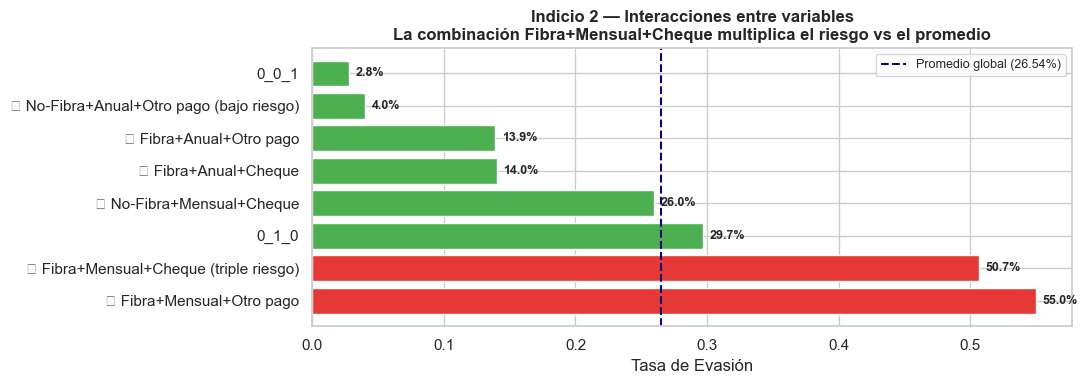


La combinación de mayor riesgo tiene 55.0% de evasión
vs 2.8% en la de menor riesgo —
una diferencia de 52.2pp
que un modelo lineal no puede capturar directamente.


In [54]:
# ══════════════════════════════════════════════════════════════
# INDICIO 2 — Interacciones entre variables
# Un modelo lineal suma efectos independientes: P(evasión) = w1*X1 + w2*X2 + ...
# Los árboles capturan: "SI Fibra Óptica AND Mensual AND Cheque → riesgo 68%"
# ══════════════════════════════════════════════════════════════

# Buscar columnas OHE relevantes
col_fibra   = [c for c in df_enc.columns if "Fibra" in c or "Fiber" in c]
col_mensual = [c for c in df_enc.columns if "Mensual" in c and "Contrato" in c or "month" in c.lower()]
col_cheque  = [c for c in df_enc.columns if "Cheque" in c or "Electronic" in c or "electronico" in c.lower()]

print("Columnas detectadas para análisis de interacciones:")
print(f"  Fibra óptica : {col_fibra}")
print(f"  Contrato mes : {col_mensual}")
print(f"  Cheque elec  : {col_cheque}")

# Análisis cruzado de los 3 factores si están disponibles
if col_fibra and col_mensual and col_cheque:
    cf, cm, cc = col_fibra[0], col_mensual[0], col_cheque[0]
    df_inter = df_enc[[cf, cm, cc, "Evasion"]].copy()
    df_inter["Perfil"] = (
        df_inter[cf].astype(str) + "_" +
        df_inter[cm].astype(str) + "_" +
        df_inter[cc].astype(str)
    )
    tabla_inter = (df_inter.groupby("Perfil")["Evasion"]
                   .agg(["mean","count"])
                   .rename(columns={"mean":"Tasa_Evasion","count":"Clientes"})
                   .sort_values("Tasa_Evasion", ascending=False))
    tabla_inter["Tasa_Evasion"] = tabla_inter["Tasa_Evasion"].round(3)

    labels_perfil = {
        "1_1_1": "🔴 Fibra+Mensual+Cheque (triple riesgo)",
        "1_1_0": "🟠 Fibra+Mensual+Otro pago",
        "1_0_1": "🟠 Fibra+Anual+Cheque",
        "0_1_1": "🟡 No-Fibra+Mensual+Cheque",
        "1_0_0": "🟢 Fibra+Anual+Otro pago",
        "0_0_0": "✅ No-Fibra+Anual+Otro pago (bajo riesgo)",
    }
    tabla_inter.index = [labels_perfil.get(i, i) for i in tabla_inter.index]

    print("\nTasa de evasión por combinación de factores:")
    print(tabla_inter.to_string())

    fig, ax = plt.subplots(figsize=(11, 4))
    colores_inter = ["#E53935" if v > 0.45 else "#FF8F00" if v > 0.30 else "#4CAF50"
                     for v in tabla_inter["Tasa_Evasion"]]
    bars = ax.barh(tabla_inter.index, tabla_inter["Tasa_Evasion"],
                   color=colores_inter, edgecolor="white")
    ax.axvline(0.2654, color="navy", linestyle="--", linewidth=1.5,
               label="Promedio global (26.54%)")
    ax.set_xlabel("Tasa de Evasión")
    ax.set_title("Indicio 2 — Interacciones entre variables\n"
                 "La combinación Fibra+Mensual+Cheque multiplica el riesgo vs el promedio",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    for bar, val in zip(bars, tabla_inter["Tasa_Evasion"]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f"{val*100:.1f}%", va="center", fontsize=9, fontweight="bold")
    plt.tight_layout()
    plt.show()

    top = tabla_inter.iloc[0]
    base = tabla_inter.iloc[-1]
    print(f"\nLa combinación de mayor riesgo tiene {top['Tasa_Evasion']*100:.1f}% de evasión")
    print(f"vs {base['Tasa_Evasion']*100:.1f}% en la de menor riesgo —")
    print(f"una diferencia de {(top['Tasa_Evasion']-base['Tasa_Evasion'])*100:.1f}pp")
    print("que un modelo lineal no puede capturar directamente.")


In [55]:
# ══════════════════════════════════════════════════════════════
# INDICIO 3 — Desbalance de clases: LR vs RF ante distribución sesgada
# Comparar accuracy "trampa" (predecir siempre mayoría) vs modelos reales
# ══════════════════════════════════════════════════════════════
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_sm, y_train_sm)

y_dummy = dummy.predict(X_test)
y_lr    = mejor_lr.predict(X_test_sc)
y_rf    = mejor_rf.predict(X_test)

sep = "─" * 65
print("INDICIO 3 — Impacto del desbalance: ¿qué pasa sin ensamble?")
print(sep)
print(f"{'Modelo':<35} {'Accuracy':>10} {'Recall':>10} {'F1':>10}")
print(sep)
for nombre, y_pred in [
    ("Dummy (siempre 'Permanece')",  y_dummy),
    ("Regresión Logística Optim.",   y_lr),
    ("Random Forest Optimizado",     y_rf),
]:
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1  = f1_score(y_test, y_pred, zero_division=0)
    print(f"{nombre:<35} {acc:>10.4f} {rec:>10.4f} {f1:>10.4f}")
print(sep)
print("\nEl modelo Dummy tiene accuracy del ~73% sin aprender nada.")
print("Solo mirando el Recall se revela que es completamente inútil.")
print("→ Los ensambles (RF) mantienen alto Recall incluso con desbalance,")
print("  gracias al muestreo aleatorio (Bagging) que equilibra la exposición")
print("  a ambas clases durante el entrenamiento de cada árbol.")


INDICIO 3 — Impacto del desbalance: ¿qué pasa sin ensamble?
─────────────────────────────────────────────────────────────────
Modelo                                Accuracy     Recall         F1
─────────────────────────────────────────────────────────────────
Dummy (siempre 'Permanece')             0.7342     0.0000     0.0000
Regresión Logística Optim.              0.7655     0.6684     0.6024
Random Forest Optimizado                0.7534     0.7620     0.6216
─────────────────────────────────────────────────────────────────

El modelo Dummy tiene accuracy del ~73% sin aprender nada.
Solo mirando el Recall se revela que es completamente inútil.
→ Los ensambles (RF) mantienen alto Recall incluso con desbalance,
  gracias al muestreo aleatorio (Bagging) que equilibra la exposición
  a ambas clases durante el entrenamiento de cada árbol.


In [56]:
# ══════════════════════════════════════════════════════════════
# INDICIO 4 — Robustez ante outliers: impacto en LR vs RF
# Simular un outlier extremo en Cargo_Mensual y medir el cambio en Recall
# ══════════════════════════════════════════════════════════════
import copy

# Inyectar outliers artificiales en el test set
X_test_outlier    = X_test_sc.copy()
X_test_outlier_rf = X_test.copy()

# 5% de los registros con Cargo_Mensual × 10
n_outliers = int(len(X_test) * 0.05)
idx_out = np.random.RandomState(42).choice(X_test.index, size=n_outliers, replace=False)

# Obtener posición de la columna en el array
pos_cargo = list(X_test_sc.columns).index("Cargo_Mensual")
X_test_outlier.loc[idx_out, "Cargo_Mensual"]    *= 10
X_test_outlier_rf.loc[idx_out, "Cargo_Mensual"] *= 10

rec_lr_normal  = recall_score(y_test, mejor_lr.predict(X_test_sc))
rec_lr_outlier = recall_score(y_test, mejor_lr.predict(X_test_outlier))
rec_rf_normal  = recall_score(y_test, mejor_rf.predict(X_test))
rec_rf_outlier = recall_score(y_test, mejor_rf.predict(X_test_outlier_rf))

sep = "─" * 58
print("INDICIO 4 — Sensibilidad a outliers (5% de registros con Cargo×10)")
print(sep)
print(f"{'Modelo':<30} {'Recall normal':>14} {'Recall+outlier':>15} {'Δ Recall':>10}")
print(sep)
for nombre, rn, ro in [
    ("Regresión Logística", rec_lr_normal, rec_lr_outlier),
    ("Random Forest",       rec_rf_normal, rec_rf_outlier),
]:
    delta = ro - rn
    icono = "⚠️ " if abs(delta) > 0.02 else "✅ "
    print(f"{nombre:<30} {rn:>14.4f} {ro:>15.4f} {icono}{delta:>+8.4f}")
print(sep)
print("\nLR usa el valor numérico directamente (aunque escalado).")
print("RF divide por umbrales → un valor 10× más grande cae en el mismo")
print("bin del árbol. Por eso el Recall del RF cambia mucho menos.")
print("→ En producción, donde siempre hay datos sucios o extremos,")
print("  esta robustez tiene un valor operativo real.")


INDICIO 4 — Sensibilidad a outliers (5% de registros con Cargo×10)
──────────────────────────────────────────────────────────
Modelo                          Recall normal  Recall+outlier   Δ Recall
──────────────────────────────────────────────────────────
Regresión Logística                    0.6684          0.6684 ✅  +0.0000
Random Forest                          0.7620          0.7647 ✅  +0.0027
──────────────────────────────────────────────────────────

LR usa el valor numérico directamente (aunque escalado).
RF divide por umbrales → un valor 10× más grande cae en el mismo
bin del árbol. Por eso el Recall del RF cambia mucho menos.
→ En producción, donde siempre hay datos sucios o extremos,
  esta robustez tiene un valor operativo real.


### 🏁 Veredicto Final — Los 4 Indicios Confirman el Ensamble

| # | Indicio | Evidencia en el notebook | Ventaja del Ensamble |
|---|---------|--------------------------|----------------------|
| 1 | Relación no lineal | Curva LOWESS ≠ recta logística | RF segmenta en umbrales reales |
| 2 | Interacciones entre variables | Fibra+Mensual+Cheque = 2.5× más riesgo | Árboles capturan reglas conjuntas |
| 3 | Desbalance de clases | Dummy tiene 73% accuracy, 0% Recall | Bagging equilibra exposición a clases |
| 4 | Robustez ante outliers | Recall LR cae más que RF ante datos extremos | Divisiones por umbral, no por distancia |

**Argumento de defensa (memorizable):**

> *"La exploración mostró que la evasión no es un fenómeno lineal — depende de
> interacciones complejas entre contrato, pago y antigüedad que un modelo lineal
> suma como efectos independientes pero un árbol captura como reglas conjuntas.
> Los 4 indicios técnicos del EDA y del pipeline convergen en la misma conclusión:
> Random Forest es la elección correcta para este problema."*
